<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewer's comment v1</h1>

Hello George!

I'm happy to review your project today 🙌

You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work can't be accepted with the red comments
</div>

Please don't remove my comments. If you have any questions, don't hesitate to respond to my comments in a different section.
    
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>     


<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v1</b>
    
<b>General Feedback</b>  
 
Hello George,  
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, I’ve returned it with some feedback to help you make the necessary improvements. You can find my more detailed feedback within your project file in the **`Reviewer's comment v1`** section.

**🚧 Suggested Tweaks & Areas for Attention**

- Keep only data from the last 3–5 years that could be used for further analysis.
    
Keep in mind that revisions are a normal and valuable part of the learning process. Use this feedback to refine your work and resubmit when you’re ready. I know you’re capable of great things, and I’m here to support you every step of the way. Keep going—you’re doing a great job! 🏄
    
And of course, if you have any questions along the way, remember that you can always reach out to your tutor for any clarification.
</div>

<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v2</b>
    
<b>General Feedback</b> 
    
Hi George, you did an amazing job! 💫 Thank you for going the extra mile and making changes to your project.

Everything is perfect now. There are no critical issues left, so your project has been accepted!

Wishing you interesting projects in the upcoming sprints! ☘️

# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job adding additional information about the project goal. It would also be helpful to share the steps you plan to complete.

</div>

In [1]:
# Import all required libraries
import pandas as pd
import math as mt
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from scipy.stats import variation

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
games = pd.read_csv('/datasets/games.csv')

In [3]:
# Display basic information about the dataset
games.info()
print(games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08  

In [4]:
# Check for duplicate entries
duplicate_count = games[games.duplicated(keep='first')].value_counts()
print(duplicate_count)

Series([], dtype: int64)


<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>  Upon performing a surface look at the dataset, here are the facts I think are important to understand about the data. The dataset consists of 16,715 records (rows) each with information about a video game released between 1980 and 2016. For each record there are 10 columns that hold the values for the 'name' of the game, the ' platform' it was released on, the 'year_of_release', the 'genre' for each game, the regional sales for North America, Europe, Japan, and Other (for sales not in the first three major regions). The columns currently hold only two different data types: 'object' and 'float64'; however, based on the column names and the information located in those columns some conversion of data types to some more appropriate will need to take place. The biggest issue I see is that the 'critic_score' and the 'user_score' are based off different scales. the 'critic_score' is based off a 0 to 100 scale, while the 'user_score' is based on a 0 to 10 scale. This will require the 'user_score' to be modified so that it represents the same scale as the 'critic_score' without losing it's value. Then there are the missing values in the 'critic_score', 'user_score', and 'rating' columns that will need to be dealt with.
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Everything is correct here. 

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
games.columns = games.columns.str.lower()

In [6]:
# Verify the changes
print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Regarding the column name changes, everything is correct. The most common convention in Python is to use snake case (e.g., `first_name`). You can read more about this naming style here:

https://levelup.gitconnected.com/case-styles-in-python-fd9591e57f86 

Using snake case improves readability and follows the standard Python style guide.
</div>

### 2.2 Data Type Conversion

In [7]:
# Check current data types
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [8]:
# Change the data type for the column label 'year_of_release' from 'float' to 'str'.
games['year_of_release'] = games['year_of_release'].apply(lambda x: int(x) if pd.notnull(x) else pd.NA).astype('Int64')

# Convert the colum 'user_score' from an object data type to a 'float' using 'to_numeric' so it can be used for the analysis. Since this column also has the value 'TBD', I used the parameter 'errors=' with 'coerce' value. This would change the 'TDB' values to a 'NaN' value.
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games['user_score'] = games['user_score'] * 10

# Replacing missing value in 'rating' column with 'Unknown'
games['rating'] = games['rating'].fillna('unknown')

# Convert 'platform', 'genre', and 'rating' columns to 'category' data type
games['platform'] = games['platform'].astype('category')
games['genre'] = games['genre'].astype('category')
games['rating'] = games['rating'].astype('category')

In [9]:
games.info()
print(games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           16715 non-null  category
dtypes: Int64(1), category(3), float64(6), object(1)
memory usage: 1.1+ MB
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES       

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>
    Since this column is for the Year of release, it would be better served for analysis if it was an string
    instead of a float data type. Also converting 'user_score' from the dtype of object to a 'float' to  a 'str'.
    This requires the use of the method to_method(). Since the 'user_score' column has at least one instance of
    'TBD' it requires the passing of 'coerce' through the parameter 'errors='. This will change all the 'TDB' value
    to 'NaN' so that the column can be used in the analysis better.
</div>

### 2.3 Handling Missing Values

In [10]:
# Examine missing values
null_values = games[games.isnull().any(axis=1)]

print(null_values)

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [11]:
# Calculate percentage of missing values per column
null_data = games.isnull().sum().sort_values(ascending=False)
null_percentage = (games.isnull().mean() * 100).sort_values(ascending=False)
null_summary = pd.DataFrame({'Null Values': null_data, 'Null Percentage': null_percentage})

print(null_summary)

                 Null Values  Null Percentage
user_score              9125        54.591684
critic_score            8578        51.319174
year_of_release          269         1.609333
name                       2         0.011965
genre                      2         0.011965
platform                   0         0.000000
na_sales                   0         0.000000
eu_sales                   0         0.000000
jp_sales                   0         0.000000
other_sales                0         0.000000
rating                     0         0.000000


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Great job checking both the absolute numbers and the percentages of missing values in your dataset. This thorough approach helps ensure you have a clear understanding of the extent of missing data and its potential impact on your analysis. 


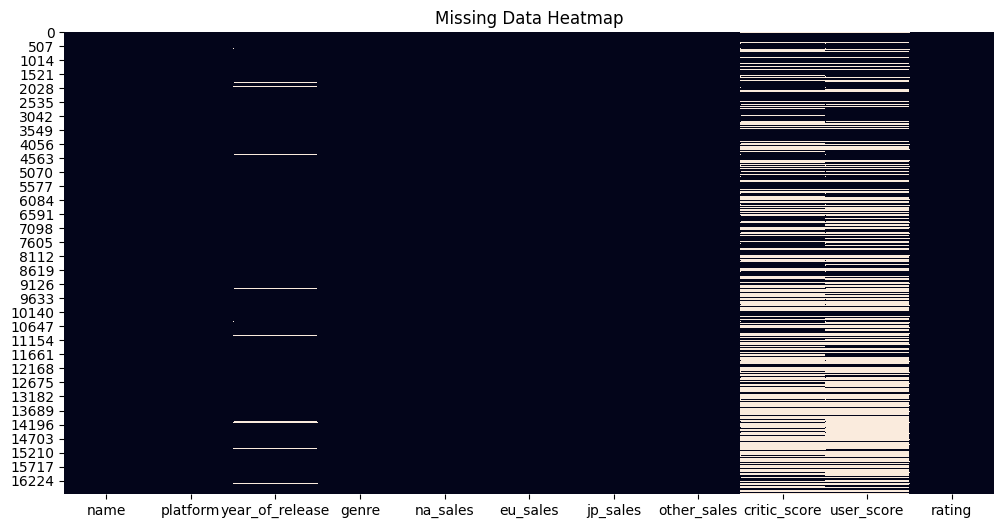

In [12]:
# Analyze patterns in missing values
plt.figure(figsize=[12,6])
sns.heatmap(games.isnull(), cbar=False)
plt.title("Missing Data Heatmap")

plt.show()

In [13]:
# Grouping the three 
critic_score_grp = games[games['critic_score'].isnull()].groupby('platform', observed=False)['name'].count().sort_values(ascending=False)
user_score_grp = games[games['user_score'].isnull()].groupby('platform', observed=False)['name'].count().sort_values(ascending=False)
rating_grp = games[games['rating'].isnull()].groupby('platform', observed=False)['name'].count().sort_values(ascending=False)
null_grp_platform_summary = pd.DataFrame({'Critic_Score': critic_score_grp, 'User_Score': user_score_grp, 'Rating': rating_grp})

print(null_grp_platform_summary)

          Critic_Score  User_Score  Rating
platform                                  
2600               133         133       0
3DO                  3           3       0
3DS                352         346       0
DC                  38          38       0
DS                1434        1635       0
GB                  98          98       0
GBA                384         567       0
GC                 108         190       0
GEN                 27          27       0
GG                   1           1       0
N64                319         319       0
NES                 98          98       0
NG                  12          12       0
PC                 259         204       0
PCFX                 1           1       0
PS                 997        1035       0
PS2                863         920       0
PS3                511         454       0
PS4                140         135       0
PSP                747         788       0
PSV                310         287       0
SAT        

              critic_score  user_score  rating
genre                                         
Action               43.90       45.68     0.0
Adventure            75.21       76.98     0.0
Fighting             51.83       53.00     0.0
Misc                 70.11       74.91     0.0
Platform             44.03       51.80     0.0
Puzzle               61.38       77.93     0.0
Racing               40.59       48.68     0.0
Role-Playing         50.80       50.40     0.0
Shooter              28.65       30.16     0.0
Simulation           59.68       60.60     0.0
Sports               49.15       53.02     0.0
Strategy             55.78       54.47     0.0


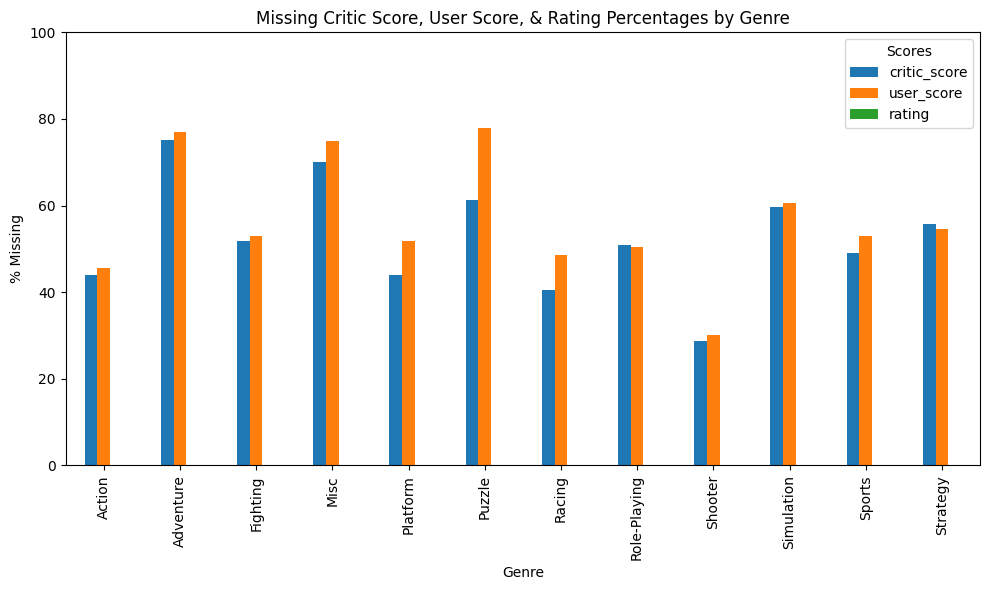

In [14]:
# Looking at missing data by Platform, then Genre, then Year of Release
null_by_genre = games.groupby('genre', observed=False)[['critic_score', 'user_score', 'rating']].apply( 
    lambda x: x.isnull().mean() * 100).round(2)
null_by_platform = games.groupby('platform', observed=False)[['critic_score', 'user_score', 'rating']].apply( 
    lambda x: x.isnull().mean() * 100).round(2)
null_by_year = games.groupby('year_of_release', observed=False)[['critic_score', 'user_score', 'rating']].apply( 
    lambda x: x.isnull().mean() * 100).round(2)

print(null_by_genre)
# Bar Plot of Null % by Genre
null_by_genre.plot(kind='bar', figsize=[10,6])
plt.title('Missing Critic Score, User Score, & Rating Percentages by Genre')
plt.xlabel('Genre')
plt.ylim(0,100)
plt.ylabel('% Missing')
plt.legend(title='Scores')
plt.tight_layout()
plt.show()

In [15]:
null_by_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 1980 to 2016
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   critic_score  37 non-null     float64
 1   user_score    37 non-null     float64
 2   rating        37 non-null     float64
dtypes: float64(3)
memory usage: 1.2+ KB


          critic_score  user_score  rating
platform                                  
2600            100.00      100.00     0.0
3DO             100.00      100.00     0.0
3DS              67.69       66.54     0.0
DC               73.08       73.08     0.0
DS               66.67       76.01     0.0
GB              100.00      100.00     0.0
GBA              46.72       68.98     0.0
GC               19.42       34.17     0.0
GEN             100.00      100.00     0.0
GG              100.00      100.00     0.0
N64             100.00      100.00     0.0
NES             100.00      100.00     0.0
NG              100.00      100.00     0.0
PC               26.59       20.94     0.0
PCFX            100.00      100.00     0.0
PS               83.29       86.47     0.0
PS2              39.94       42.57     0.0
PS3              38.39       34.11     0.0
PS4              35.71       34.44     0.0
PSP              61.79       65.18     0.0
PSV              72.09       66.74     0.0
SAT        

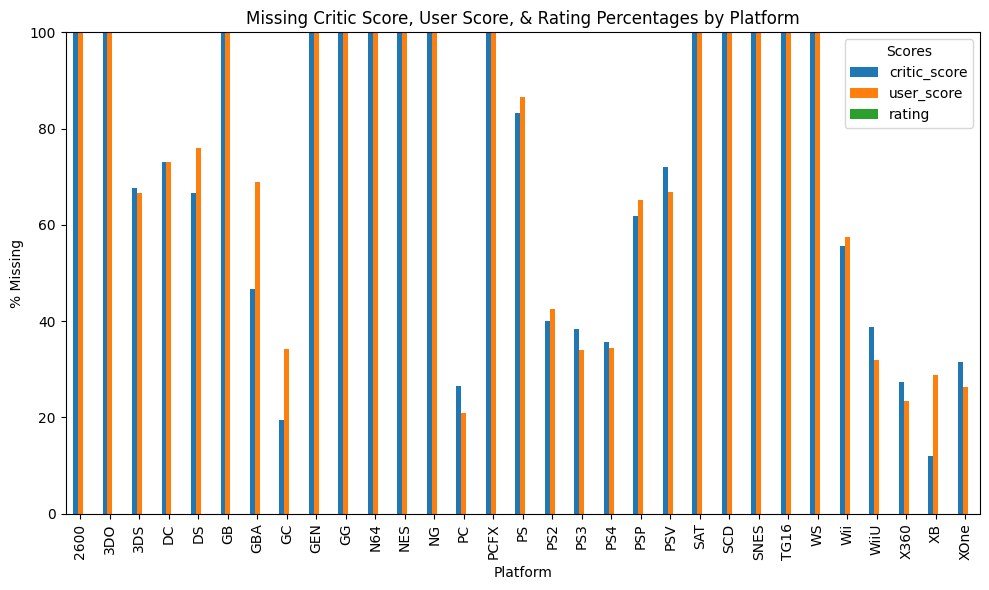

In [16]:
print(null_by_platform)

# Bar Plot of Null % by Platform
null_by_platform.plot(kind='bar', figsize=[10,6])
plt.title('Missing Critic Score, User Score, & Rating Percentages by Platform')
plt.xlabel('Platform')
plt.ylim(0,100)
plt.ylabel('% Missing')
plt.legend(title='Scores')
plt.tight_layout()
plt.show()

                 critic_score  user_score  rating
year_of_release                                  
1980                   100.00      100.00     0.0
1981                   100.00      100.00     0.0
1982                   100.00      100.00     0.0
1983                   100.00      100.00     0.0
1984                   100.00      100.00     0.0
1985                    92.86       92.86     0.0
1986                   100.00      100.00     0.0
1987                   100.00      100.00     0.0
1988                    93.33       93.33     0.0
1989                   100.00      100.00     0.0
1990                   100.00      100.00     0.0
1991                   100.00      100.00     0.0
1992                    97.67       97.67     0.0
1993                   100.00      100.00     0.0
1994                    99.17       99.17     0.0
1995                   100.00      100.00     0.0
1996                    96.96       96.96     0.0
1997                    94.12       93.77     0.0


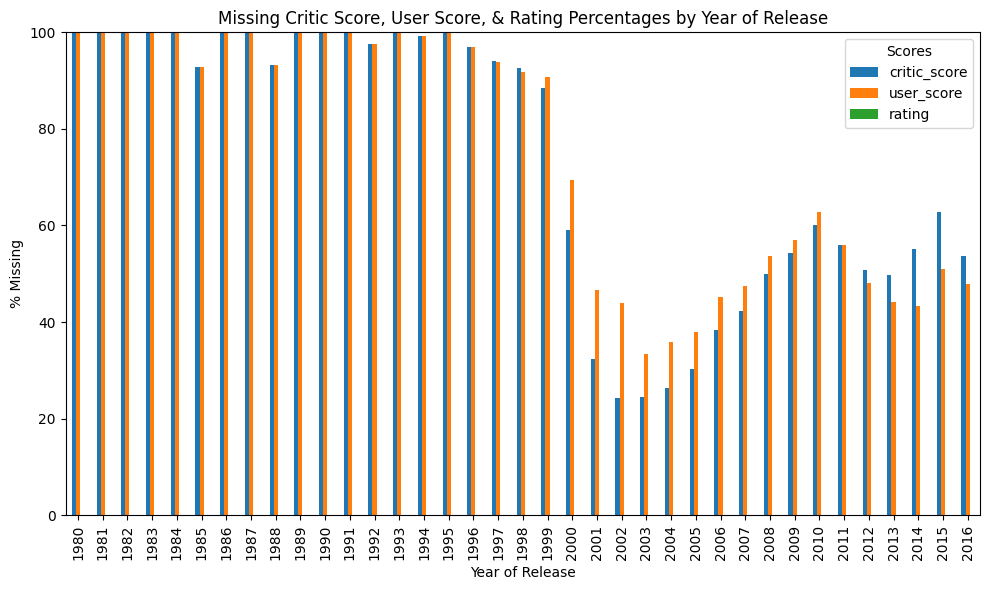

In [17]:
print(null_by_year)

# Bar Plot of Null % by Year of Release
null_by_year.plot(kind='bar', figsize=[10,6])
plt.title('Missing Critic Score, User Score, & Rating Percentages by Year of Release')
plt.xlabel('Year of Release')
plt.ylim(0,100)
plt.ylabel('% Missing')
plt.legend(title='Scores')
plt.tight_layout()
plt.show()

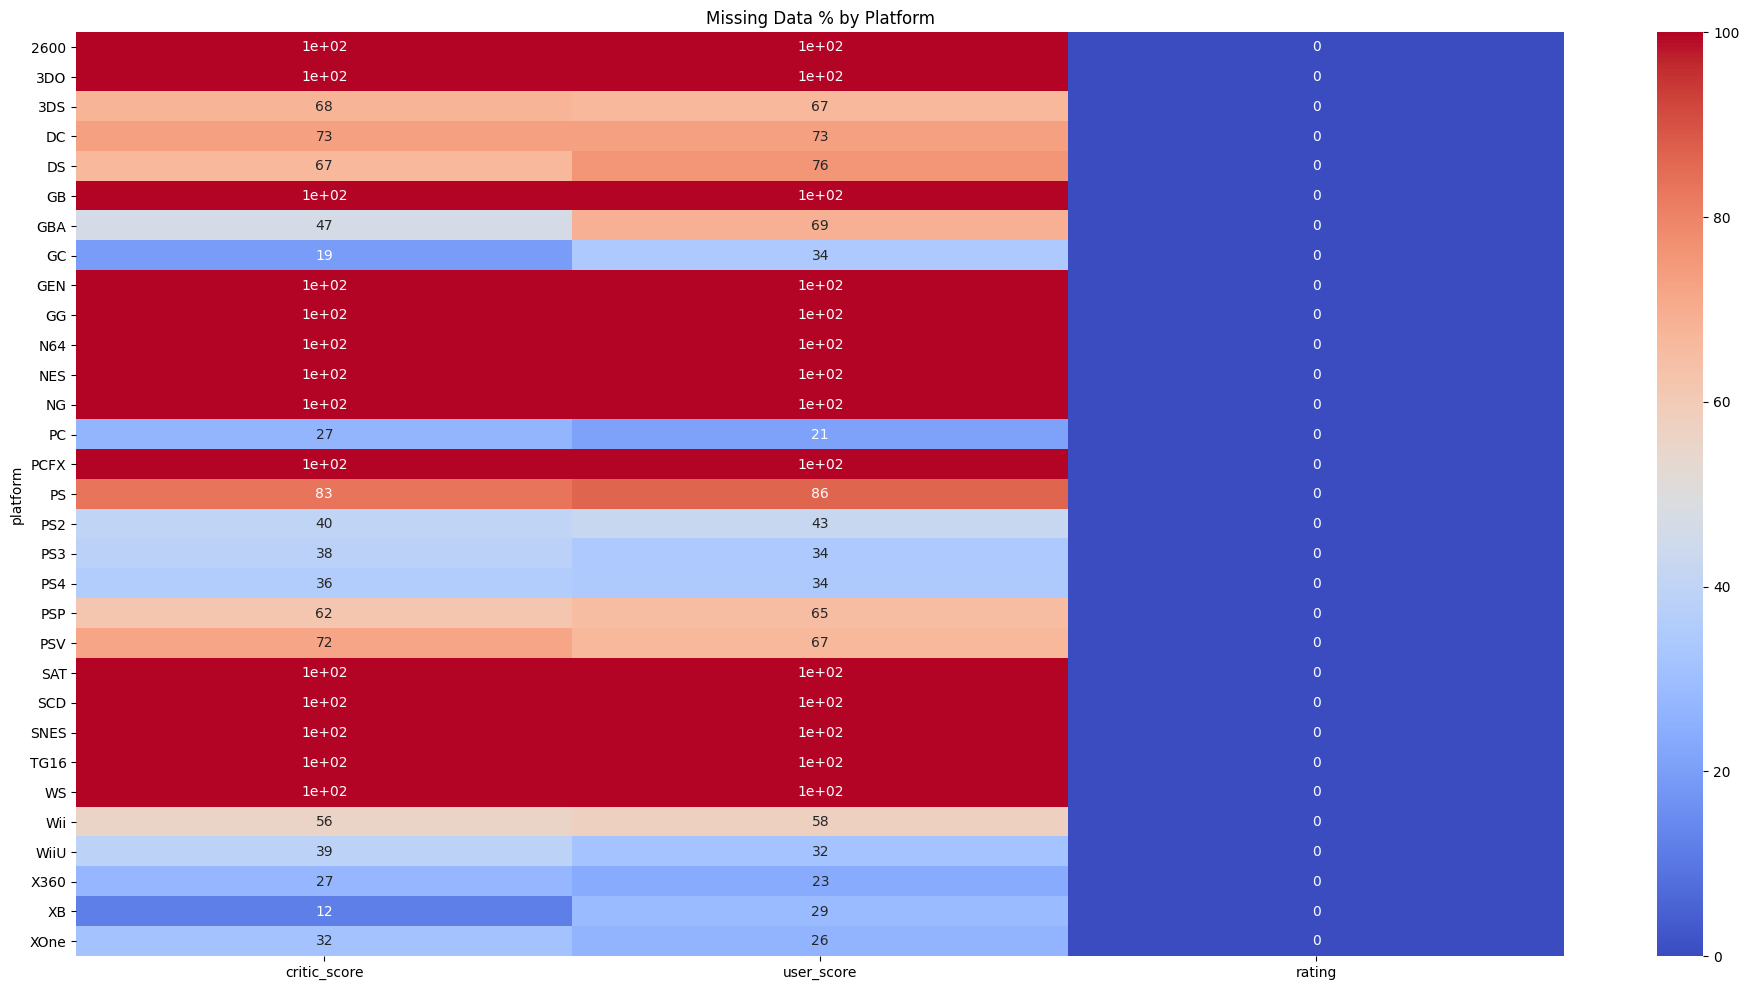

In [18]:
# Create heatmap for % missing by Platform
plt.figure(figsize=[24,12])
sns.heatmap(null_by_platform, annot=True, cmap='coolwarm')
plt.title("Missing Data % by Platform")
plt.show()

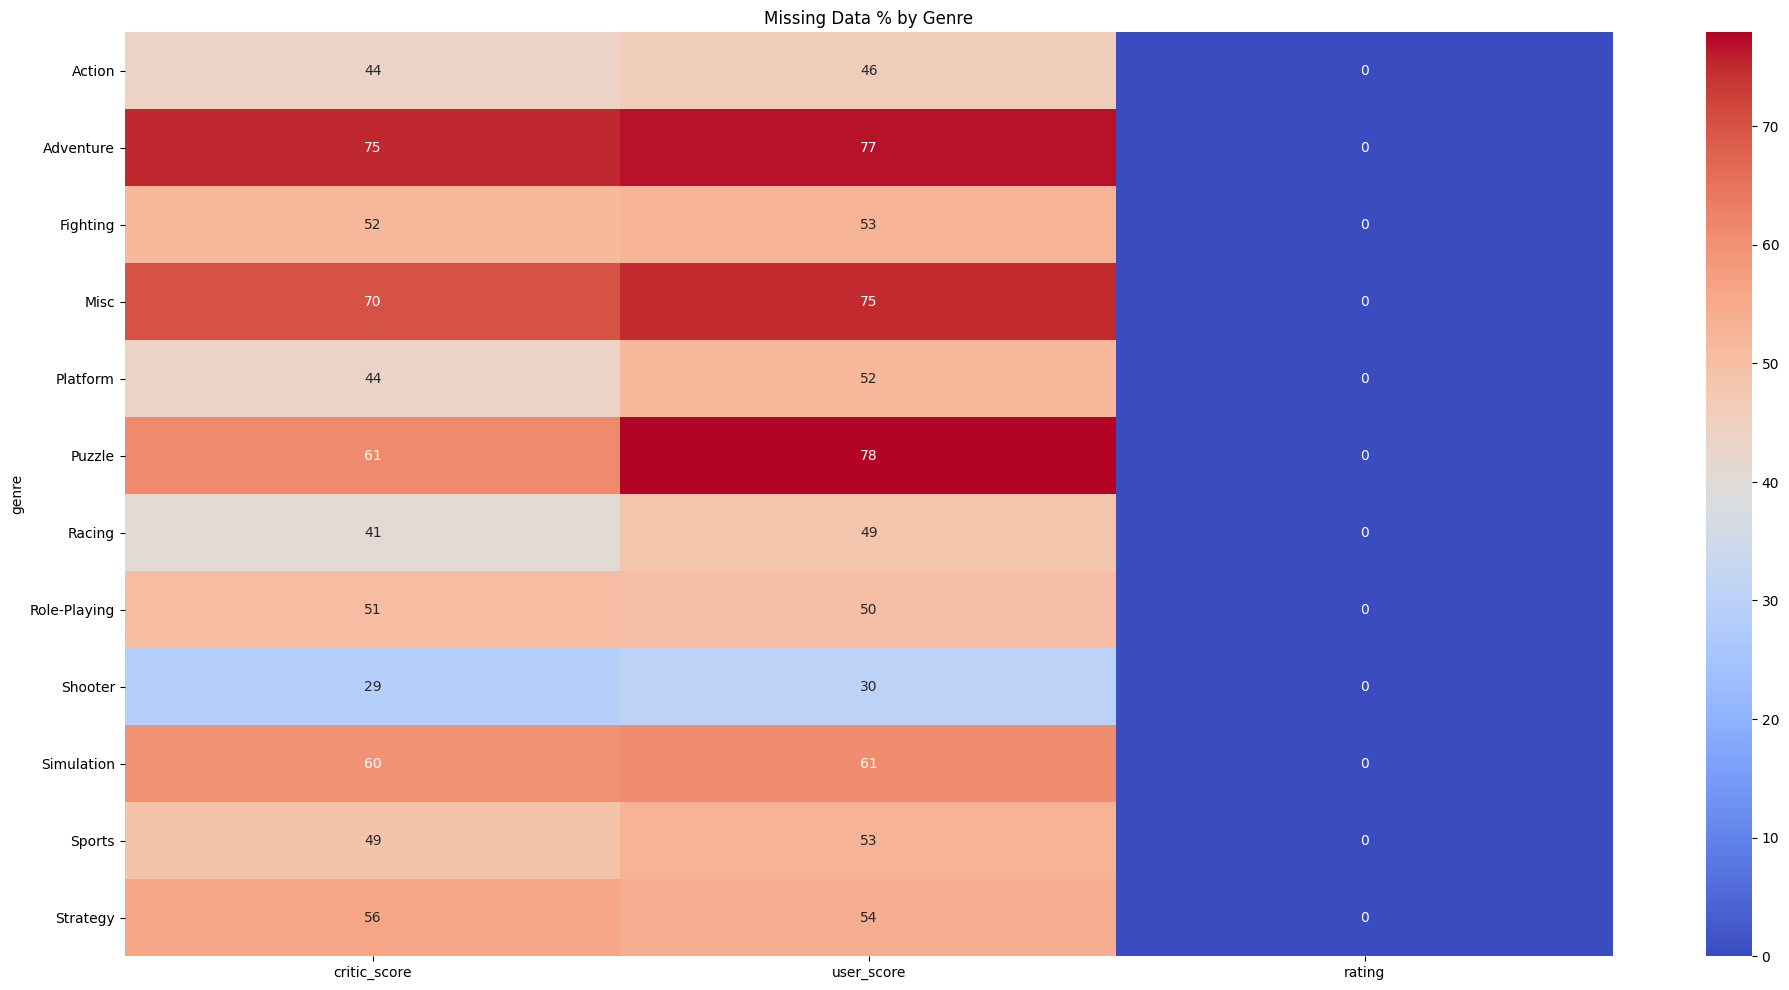

In [19]:
# Create heatmap for % missing by Genre
plt.figure(figsize=[24, 12])
sns.heatmap(null_by_genre, annot=True, cmap='coolwarm')
plt.title("Missing Data % by Genre")
plt.show()

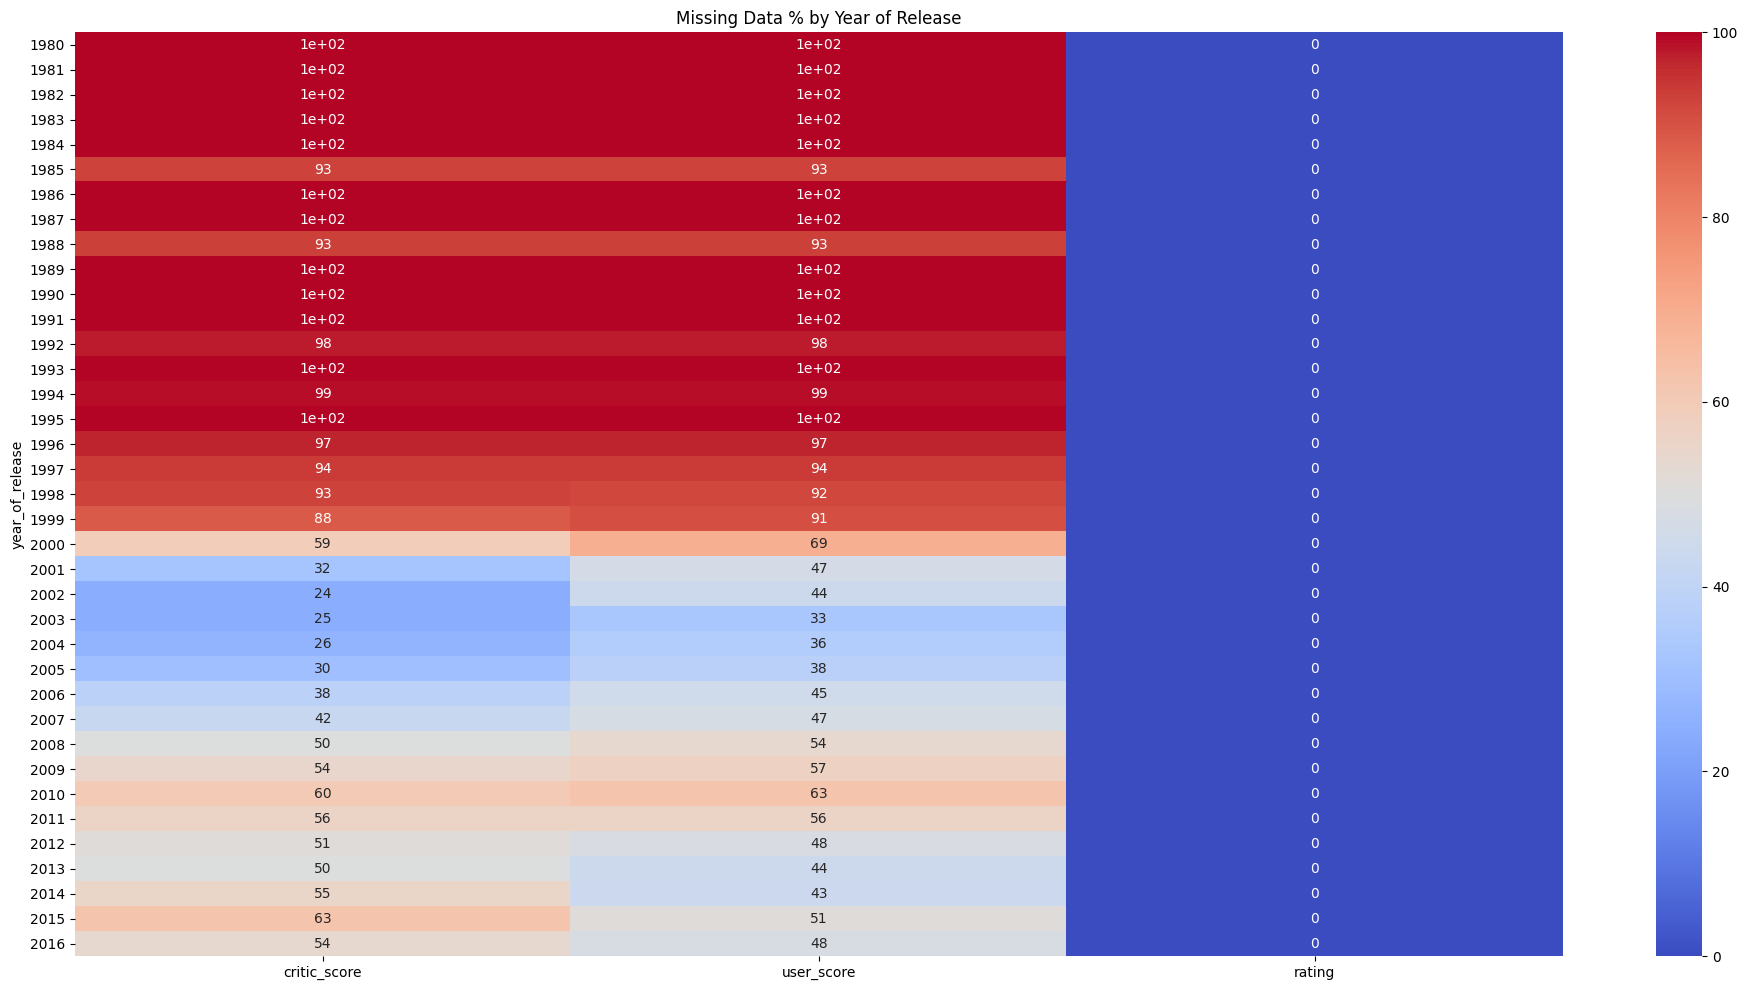

In [20]:
# Create heatmap for % missing by Year of Release
plt.figure(figsize=[24, 12])
sns.heatmap(null_by_year, annot=True, cmap='coolwarm')
plt.title("Missing Data % by Year of Release")
plt.show()

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b> In this stretch of the analysis, I took a look at the percentage of missing values. As you can see in the early years of this dataset, almost every game was missing the 'critic_score', 'user_score', and 'rating'. this trend spanned roughly 20yrs and didn't start trending down until 2001. However, by 2005 the trend began to slope back up...especially in regards to 'critic_score' and 'user_score'. The 'rating' remained relatively low considering the upturn of the other two. This is probably due to the fact all new games received an ESRB rating starting in 1994. For this reason I filled in all the 'NaN' values in the rating column with 'unknown'. I do not believe this column will have much effect on the analysis performed later to be able to present my suggestion for the 2017 sales campaign.    
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job evaluating the missing values-everything is correct here! 👏 

### 2.4 Calculate Total Sales

In [21]:
# Calculate total sales across all regions and put them in a different column
# For original DF
games['total_sales'] = (games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales'])

#games.info()
print(games.head(20))

                                            name platform  year_of_release  \
0                                     Wii Sports      Wii             2006   
1                              Super Mario Bros.      NES             1985   
2                                 Mario Kart Wii      Wii             2008   
3                              Wii Sports Resort      Wii             2009   
4                       Pokemon Red/Pokemon Blue       GB             1996   
5                                         Tetris       GB             1989   
6                          New Super Mario Bros.       DS             2006   
7                                       Wii Play      Wii             2006   
8                      New Super Mario Bros. Wii      Wii             2009   
9                                      Duck Hunt      NES             1984   
10                                    Nintendogs       DS             2005   
11                                 Mario Kart DS       DS       

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job-everything is correct here!

As an alternative approach, you could also calculate total sales using the following method:
    
```python
games_df['total_sales'] = games_df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
```

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [22]:
# Create a DataFrame with game releases by year
yearly_count = games.groupby(games['year_of_release'])['name'].count().reset_index(name='game_count')
print(yearly_count)

    year_of_release  game_count
0              1980           9
1              1981          46
2              1982          36
3              1983          17
4              1984          14
5              1985          14
6              1986          21
7              1987          16
8              1988          15
9              1989          17
10             1990          16
11             1991          41
12             1992          43
13             1993          60
14             1994         121
15             1995         219
16             1996         263
17             1997         289
18             1998         379
19             1999         338
20             2000         350
21             2001         482
22             2002         829
23             2003         775
24             2004         762
25             2005         939
26             2006        1006
27             2007        1197
28             2008        1427
29             2009        1426
30      

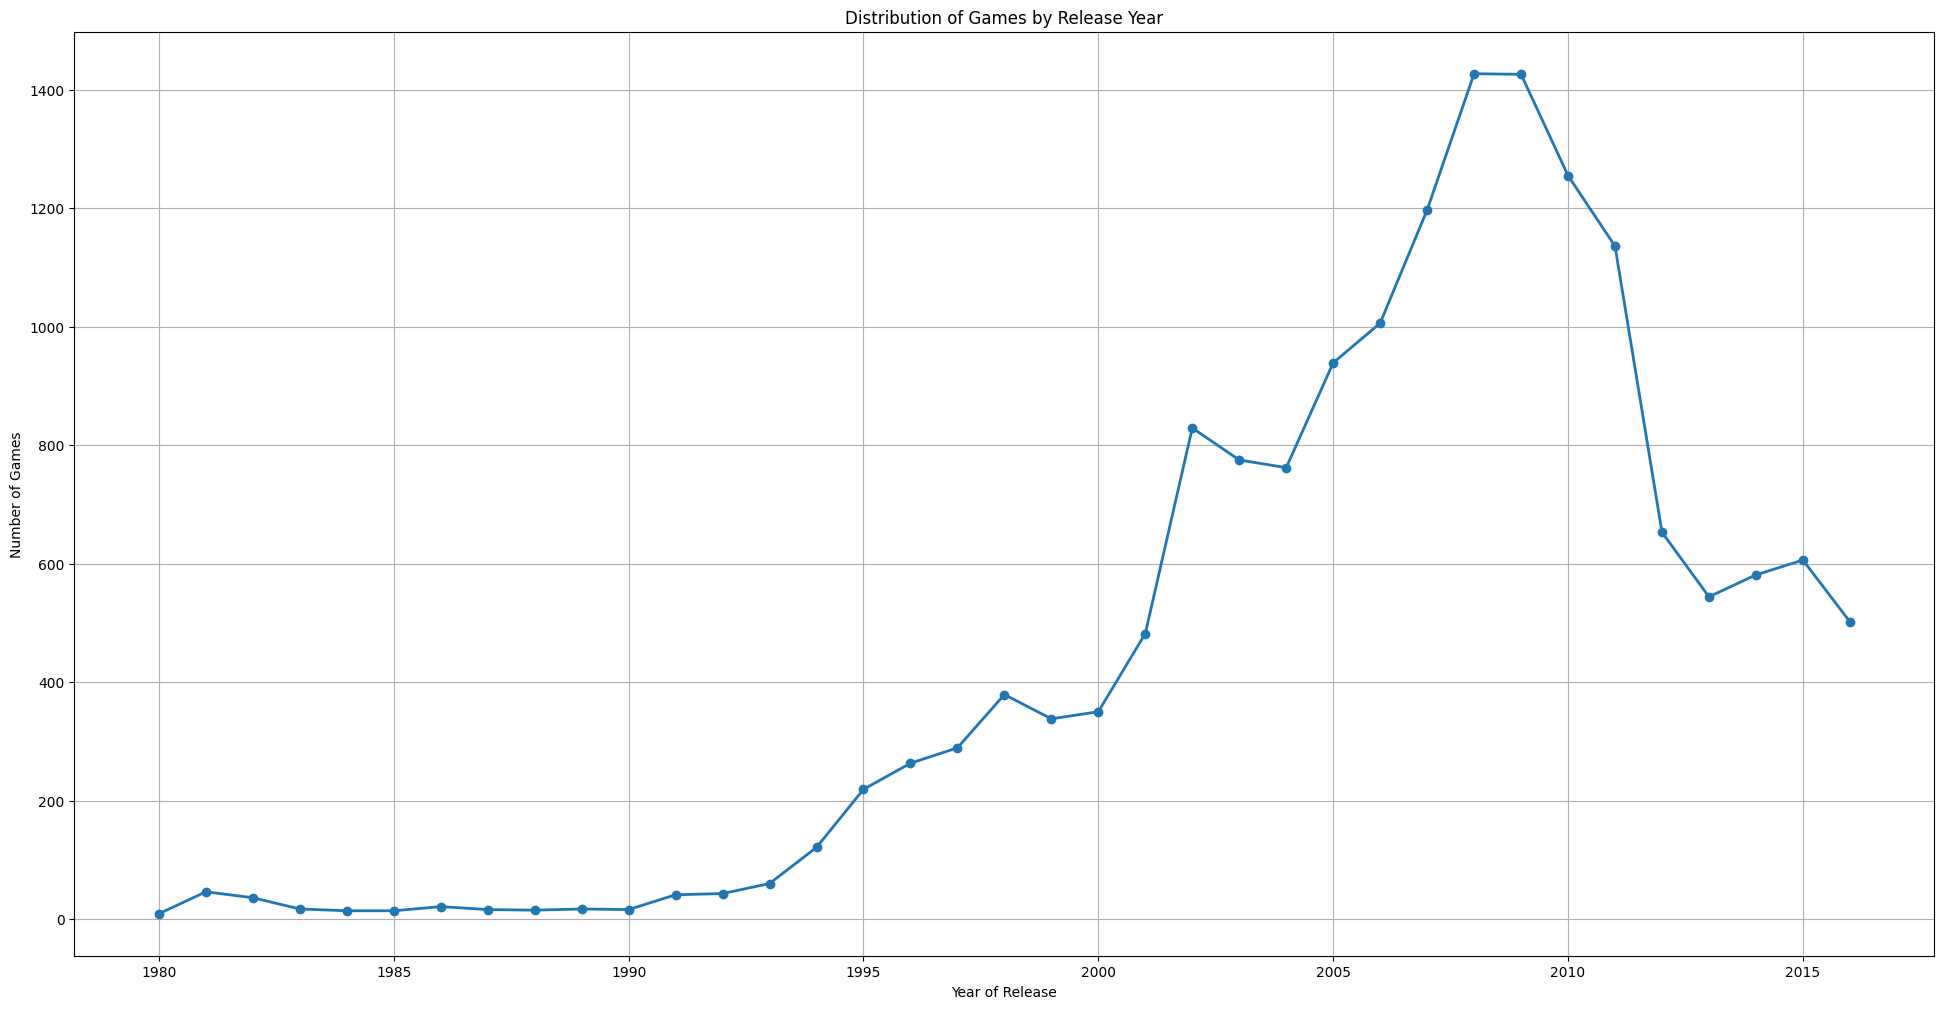

In [23]:
# Visualize the distribution of games across years
plt.figure(figsize=[24,12])
plt.plot(
    yearly_count['year_of_release'], 
    yearly_count['game_count'],
    marker='o', linestyle='-', linewidth=2
)
plt.title('Distribution of Games by Release Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')
plt.grid(True)
plt.tight_layout

plt.show()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Great, it looks like there were almost no games before 1995.

</div>

      game_releases  YoY_growth_%
1980              9          0.00
1981             46        411.11
1982             36        -21.74
1983             17        -52.78
1984             14        -17.65
1985             14          0.00
1986             21         50.00
1987             16        -23.81
1988             15         -6.25
1989             17         13.33
1990             16         -5.88
1991             41        156.25
1992             43          4.88
1993             62         44.19
1994            121         95.16
1995            219         80.99
1996            263         20.09
1997            289          9.89
1998            379         31.14
1999            338        -10.82
2000            350          3.55
2001            482         37.71
2002            829         71.99
2003            775         -6.51
2004            762         -1.68
2005            939         23.23
2006           1006          7.14
2007           1197         18.99
2008          

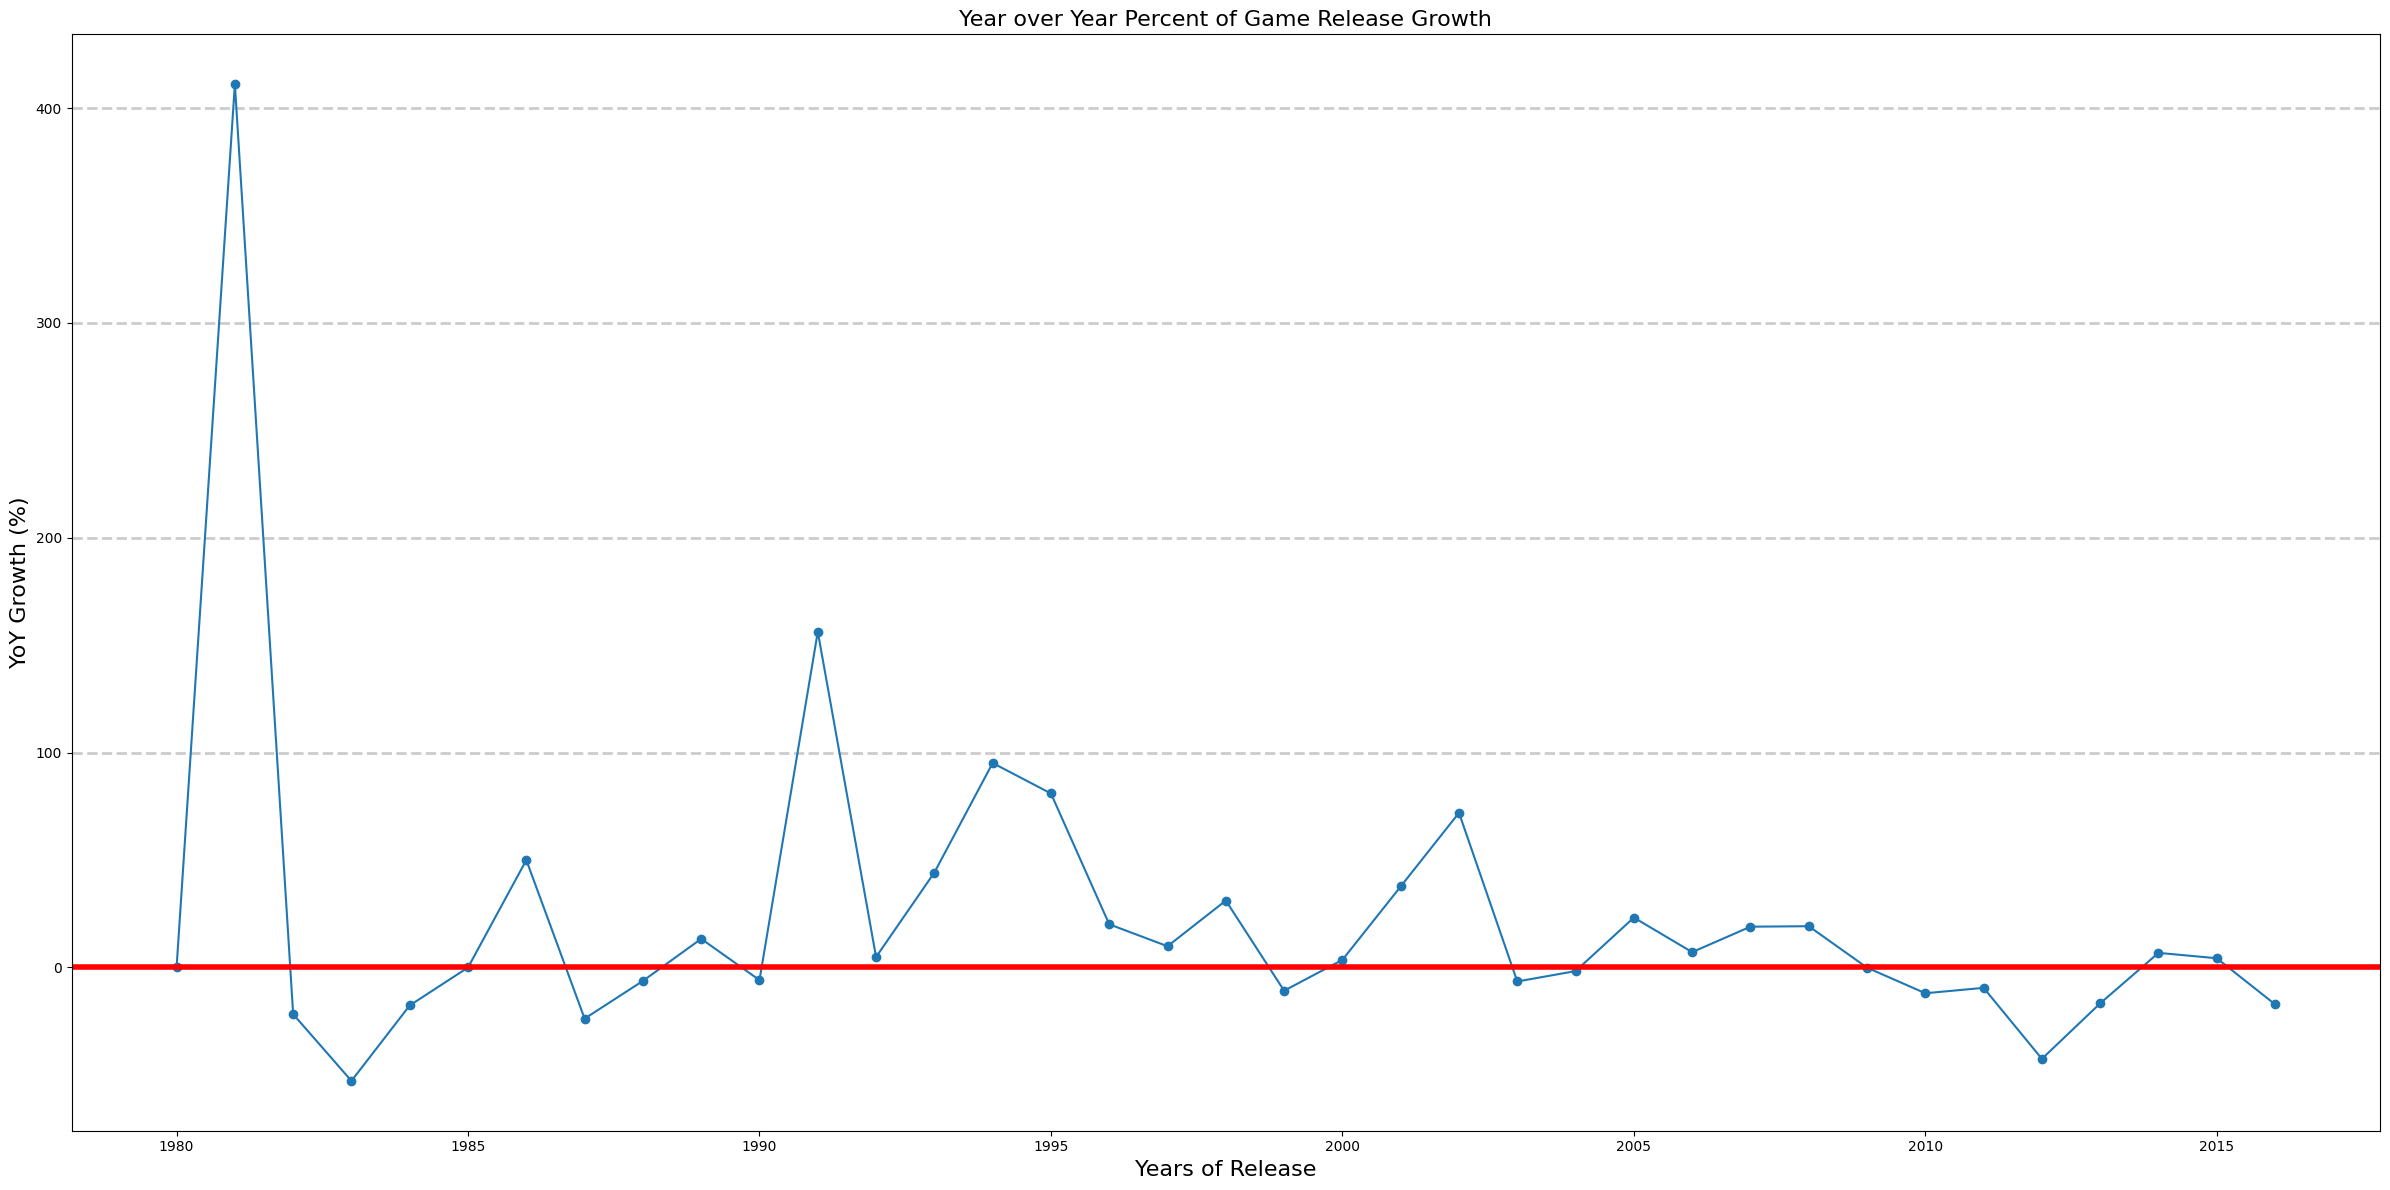

In [24]:
# Calculating YoY growth in Game Release
# Step 1: Group by year and count the number of releases
yearly_counts = games['year_of_release'].value_counts().sort_index()

# Step 2: Convert to DF
yearly_df = yearly_counts.to_frame(name='game_releases')

#Step 3: Calculate YoY growth with rounding
yearly_df['YoY_growth_%'] = (yearly_df['game_releases'].pct_change() * 100).astype(float).fillna(0)
yearly_df['YoY_growth_%'] = yearly_df['YoY_growth_%'].round(2)

print(yearly_df)

yearly_df['YoY_growth_%'].plot(
    kind='line',
    figsize=[24,12],
    marker='o'
)
plt.title('Year over Year Percent of Game Release Growth', fontsize=16)
plt.xlabel('Years of Release', fontsize=16)
plt.ylabel('YoY Growth (%)', fontsize=16)
plt.grid(axis='y', color='black', linestyle='--', linewidth=2, alpha=0.2)
plt.axhline(y=0, color='red', linestyle='-', linewidth=4)
plt.tight_layout()

plt.show()

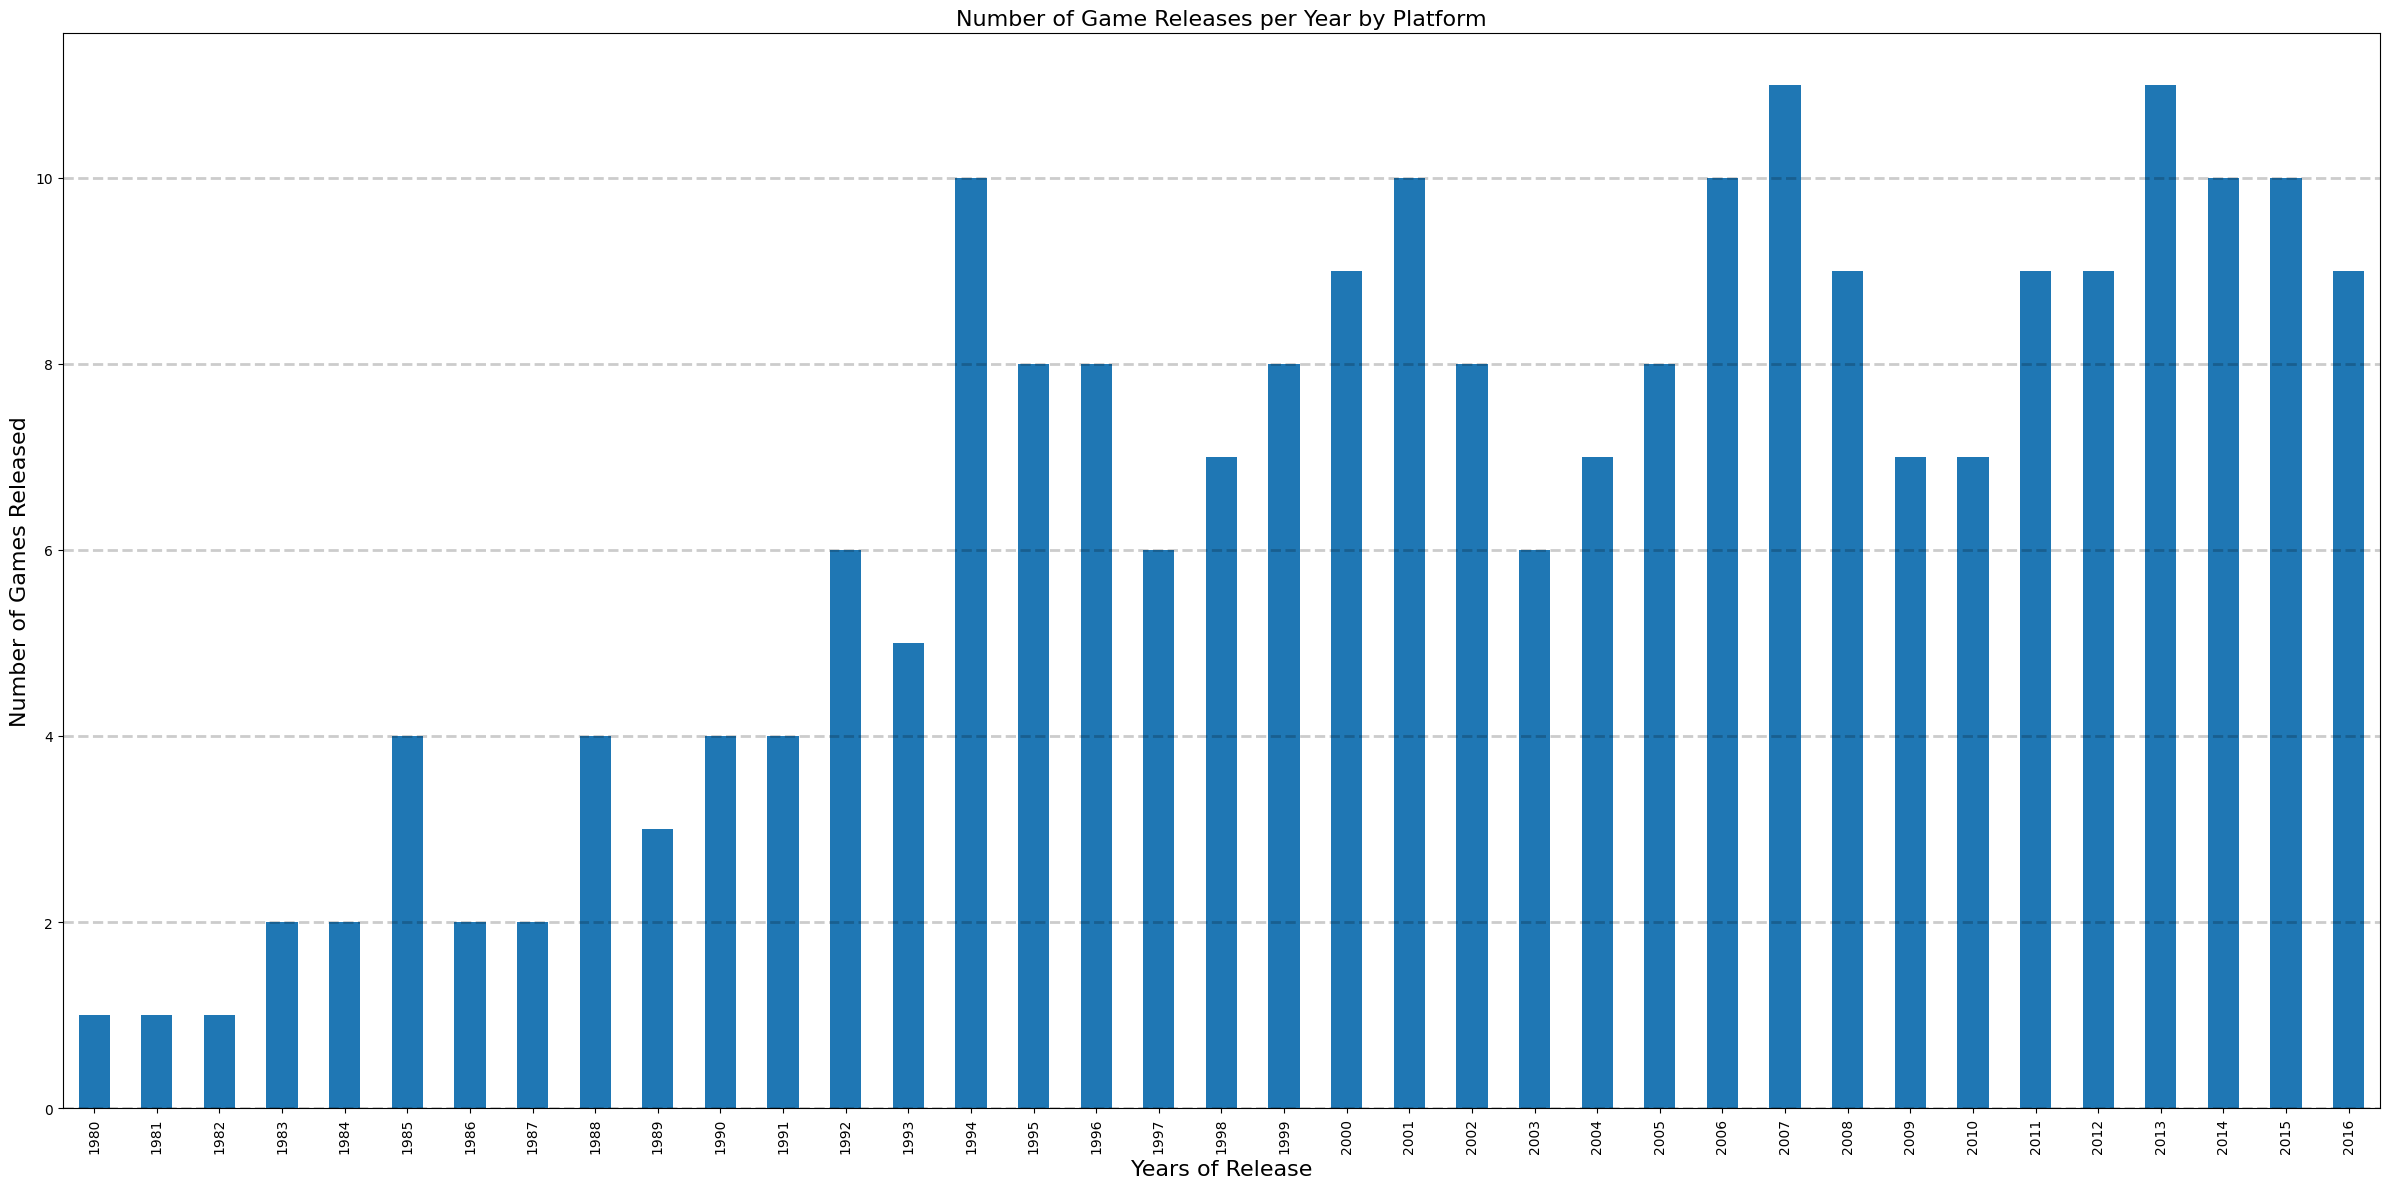

In [25]:
# Display summary statistics for each year
summary_stats = games.groupby('year_of_release')[['critic_score', 'user_score']].describe().round(2)
platforms_per_year = games.groupby('year_of_release')['platform'].nunique()

platforms_per_year.plot(kind='bar', figsize=[24,12])
plt.title('Number of Game Releases per Year by Platform', fontsize=16)
plt.xlabel('Years of Release', fontsize=16)
plt.ylabel('Number of Games Released', fontsize=16)
plt.grid(axis='y', color='black', linestyle='--', linewidth=2, alpha=0.2)
plt.tight_layout()

plt.show()

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b> Student's Comment Answers to Questions to Consider: </b>
    1. When looking at the YoY growth of game releases, there are a few years that show significant growth. First is 1981; however, this is a bit skewed as it is so close to the beginning of the dataset and more than likely within the first few years where video games were ever released. The next set of years with significant growth YoY would be 1991 - 2002. Then a couple of years of minor decline, with a rebound in 2005 and peaking in 2008. From 2009-2016 there has been a steady decline of game releases per year.
    2. The biggest pattern I see is that game releases come in waves where they build for a couple of years and then decline for 2-3 years before making a rebound. However, since 2010, the market has been a little more stable.
    3. I believe there is enough recent data to make accurate predictions for 2017. The pattern mentioned above will allow us to predict the next few years with a certain amount of accuracy.
</div>

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [26]:
# Calculate total sales by platform and year
sales_by_platform_pvt = games.pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales',
    observed=False
).round(2)

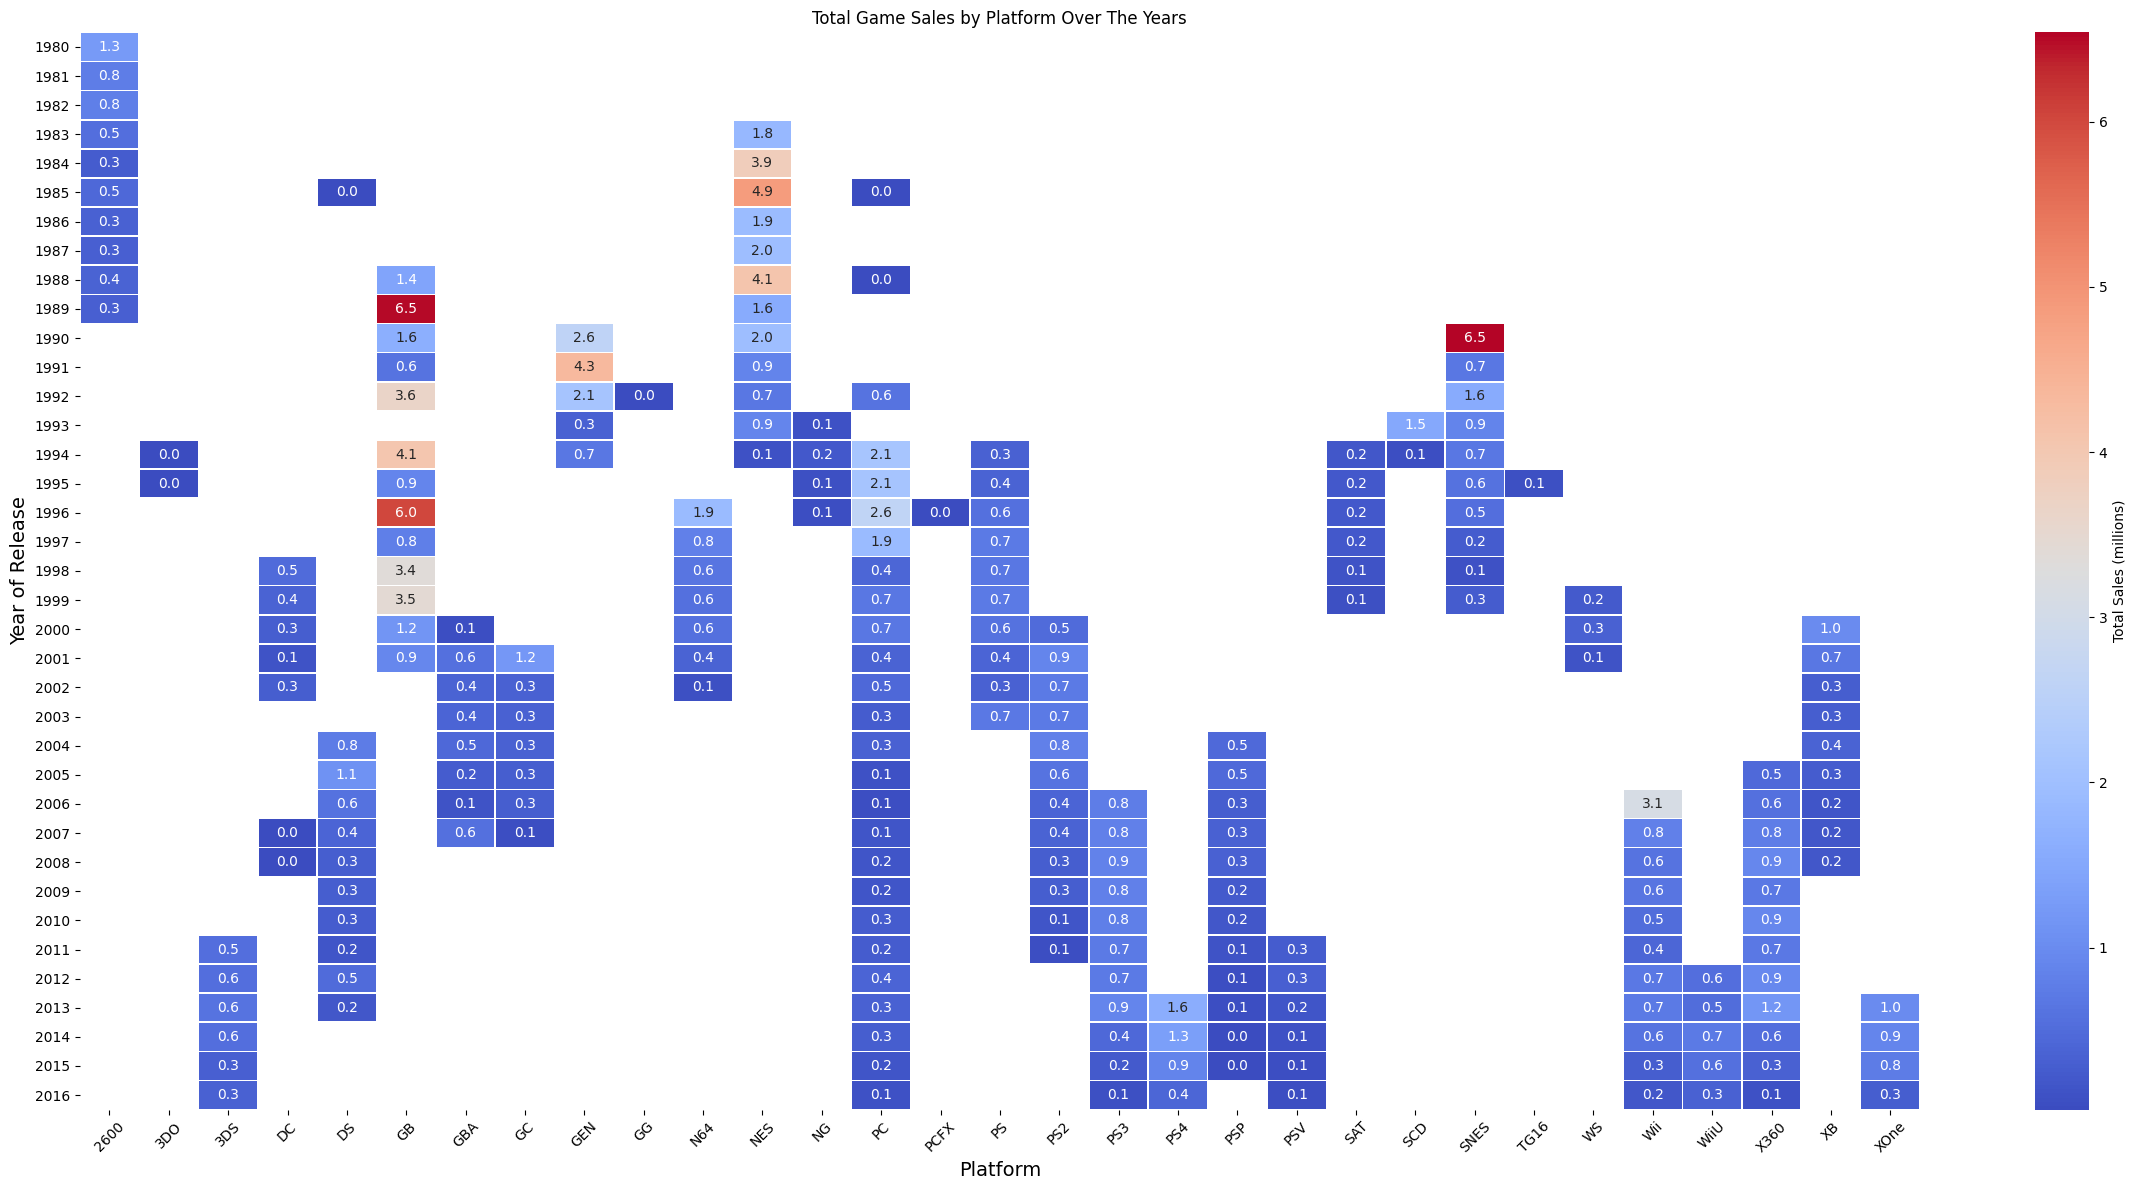

In [27]:
# Create a heatmap of platform sales over time
plt.figure(figsize=[24,12])

sns.heatmap(
    sales_by_platform_pvt,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Total Sales (millions)'}
)

plt.title('Total Game Sales by Platform Over The Years')
plt.xlabel('Platform', fontsize=14)
plt.ylabel('Year of Release', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Identify platforms with declining sales
sales_trends = games.groupby(['year_of_release', 'platform'], observed=False)['total_sales'].sum().unstack()

declining_platforms = []

# Step 1: Compute YoY change
sales_yoy = sales_trends.pct_change() * 100

# Step 2: Loop through each platform
for platform in sales_trends.columns:
    # Step 3: Identify active years (non-zero, non-null sales)
    active_sales = sales_trends[platform].dropna()
    active_sales = active_sales[active_sales > 0]

    if len(active_sales) < 4:
        continue             # Not enough data to detect a 3-period decline

    # Step 4: Get YoY values for active years only
    yoy = sales_yoy[platform].loc[active_sales.index]

    # Step 5: Find 3 consecutive negative YoY periods
    decline_flags = yoy < 0
    if any(decline_flags.rolling(3).sum() == 3):
        declining_platforms.append(platform)

print('Platforms with consistent sales decline during their active years: ')
print(declining_platforms)

Platforms with consistent sales decline during their active years: 
['2600', '3DS', 'DS', 'GBA', 'GC', 'N64', 'PS', 'PS2', 'PS3', 'PSP', 'SAT', 'SNES', 'Wii', 'X360', 'XB']


In [29]:
# Identify platforms with consistent sales over time
cv_filtered = {}

for platform in sales_trends.columns:
    sales = sales_trends[platform].dropna()
    sales = sales[sales > 0]

    if len(sales) >= 3:
        mean = sales.mean()
        std = sales.std()
        cv = std / mean if mean != 0 else float('inf')
        cv_filtered[platform] = cv

# Convert to Series
cv_filtered = pd.Series(cv_filtered).sort_values().round(2)

# Filter Out Platforms Below the Threshold
consistent_platforms = cv_filtered[cv_filtered < 0.75]

print('Platforms with consistent sales during their active years:')
print(consistent_platforms)

Platforms with consistent sales during their active years:
WS      0.42
3DS     0.43
WiiU    0.43
XOne    0.51
PS4     0.52
PSV     0.53
PS3     0.65
GC      0.67
GEN     0.69
N64     0.70
SAT     0.71
X360    0.72
dtype: float64


In [30]:
# Determining the Typical Lifecycle of a game platform
platform_lifecycle = {}

for platform in sales_trends.columns:
    sales = sales_trends[platform].dropna()
    sales = sales[sales > 0]

    if not sales.empty:
        launch_year = sales.index.min()
        peak_year = sales.idxmax()
        eol_year = sales.index.max()
        total_years = eol_year - launch_year +1
        peak_sales = sales.max()

        platform_lifecycle[platform] = {
            'launch_year': launch_year,
            'peak_year': peak_year,
            'eol_year': eol_year,
            'lifecycle_length': total_years,
            'peak_sales': peak_sales
        }

# Turn dictionary into a DF
lifecycle = pd.DataFrame.from_dict(platform_lifecycle, orient= 'index')
lifecycle = lifecycle.sort_values(by='lifecycle_length', ascending=False)

print(lifecycle['lifecycle_length'].mean().round(2))

8.61


<div class="alert alert-info"; style="border-left: 7px solid blue">
<b> Student's Comment Answers to Questions to Consider: </b>
    1.  Running through the data and using a threshold of 0.75 on the active years of a platform, the following platforms consistently show sales over time: WS, 3DS, WiiU, XOne, PS4, PSV, PS3, GC, GEN, N64, SAT, and the X360.
    2. Using the heatmap above, it is easy to identify which platforms have disappeared from the market: 2600, 3DO, DC, DS, GB, GBA, GC, GEN, GG, N64, NG, PCFX, PS, PS2, PSP, SAT, SCD, SNES, TG16, WS, and the XB.
    3.  To get the typical lifecycle of a gaming platform from this data I followed these steps to get an average lifespan of 8.61yrs. Step 1: Identify the index for of the row for a platform with positive sales, this would be the 'launch_year'. Step 2: Identify the 'peak_year' where sales where at their highest. Step 3: Identify the index of the platform where there were any positive sales, this would be the 'eol_year' (End of Life Year). Step 4: I then subtracted the 'launch_year' from the 'eol_year' then add a year to count for the Launch year. Step 5: Convet the dictionary created into a Dataframe. Step 6: Calculate the mean of the 'lifecycle_length' and round to 2 decimal points.
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
That is a nice way to check platform life cycle. We can see that only a small subset of the platform still has sales.

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [31]:
# Your code here to filter the dataset to relevant years
# Example:relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years # df_relevant = df[df['year_of_release'].isin(relevant_years)]
relevant_years = []

# Justify your choice with data
# Step 1: Look at Data Completeness
filtered = null_by_year[
    (null_by_year['critic_score'] < 50) &
    (null_by_year['user_score'] < 50)
]

relevant_years = filtered.index.tolist()

# Step 2: Look at Sales Volume Threshold
yearly_sales = games.groupby('year_of_release', observed=False)['total_sales'].sum()

relevant_sales_years = yearly_sales[yearly_sales >= 250.0].index


# Step 3: Cross checking the Data Completeness with teh Sales Volume Threshold to come up with teh final relevant
final_relevant_years = set(relevant_years).intersection(relevant_sales_years)

print(final_relevant_years)

{2001, 2002, 2003, 2004, 2005, 2006, 2007, 2013}


In [32]:
# Visualization that shows the decline Post-2007 and why I chose these years as relevant years
# Step 1: Filter DF to only show 2000 - 2016
year_range = range(2000,2017)

games_filtered = games[games['year_of_release'].isin(year_range)]
games_count_filtered = yearly_count[yearly_count['year_of_release'].isin(year_range)]
missing_values_filtered = (
    null_by_year[null_by_year.index.isin(year_range)]
    .reset_index()[['year_of_release', 'critic_score', 'user_score']]
)
missing_values_filtered = pd.DataFrame(
    missing_values_filtered,
    columns=['year_of_release', 'critic_score', 'user_score']
)

# Step 2: Aggregate Total Sales
annual_sales = games_filtered.groupby('year_of_release', observed=False)['total_sales'].sum()

print(games_filtered.head())
print(games_count_filtered.head())
print(missing_values_filtered.head())

                    name platform  year_of_release     genre  na_sales  \
0             Wii Sports      Wii             2006    Sports     41.36   
2         Mario Kart Wii      Wii             2008    Racing     15.68   
3      Wii Sports Resort      Wii             2009    Sports     15.61   
6  New Super Mario Bros.       DS             2006  Platform     11.28   
7               Wii Play      Wii             2006      Misc     13.96   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0        80.0      E   
2     12.76      3.79         3.29          82.0        83.0      E   
3     10.93      3.28         2.95          80.0        80.0      E   
6      9.14      6.50         2.88          89.0        85.0      E   
7      9.18      2.93         2.84          58.0        66.0      E   

   total_sales  
0        82.54  
2        35.52  
3        32.77  
6        29.80  
7        28.91  
    year_of_release  game_

<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Reviewer's comment v1:</b>

    
You did a great job finding the platform lifespan. 
    
However, for the further investigation it is uncommon to use data for more than 2-3 years when forecasting next year's sales, even in the case of traditional businesses. And in the dynamic computer games industry, taking longer time intervals should be avoided as it will definitely lead to tracking some obsolete trends. But you shouldn't take too short a period either.
    
Here I can advise checking 2014-2016 / 2013-2016 to evaluate only the latest data. 
    
Could you please update that and make sure that this filtered dataframe is being used in the rest of the project?

<function matplotlib.pyplot.show(close=None, block=None)>

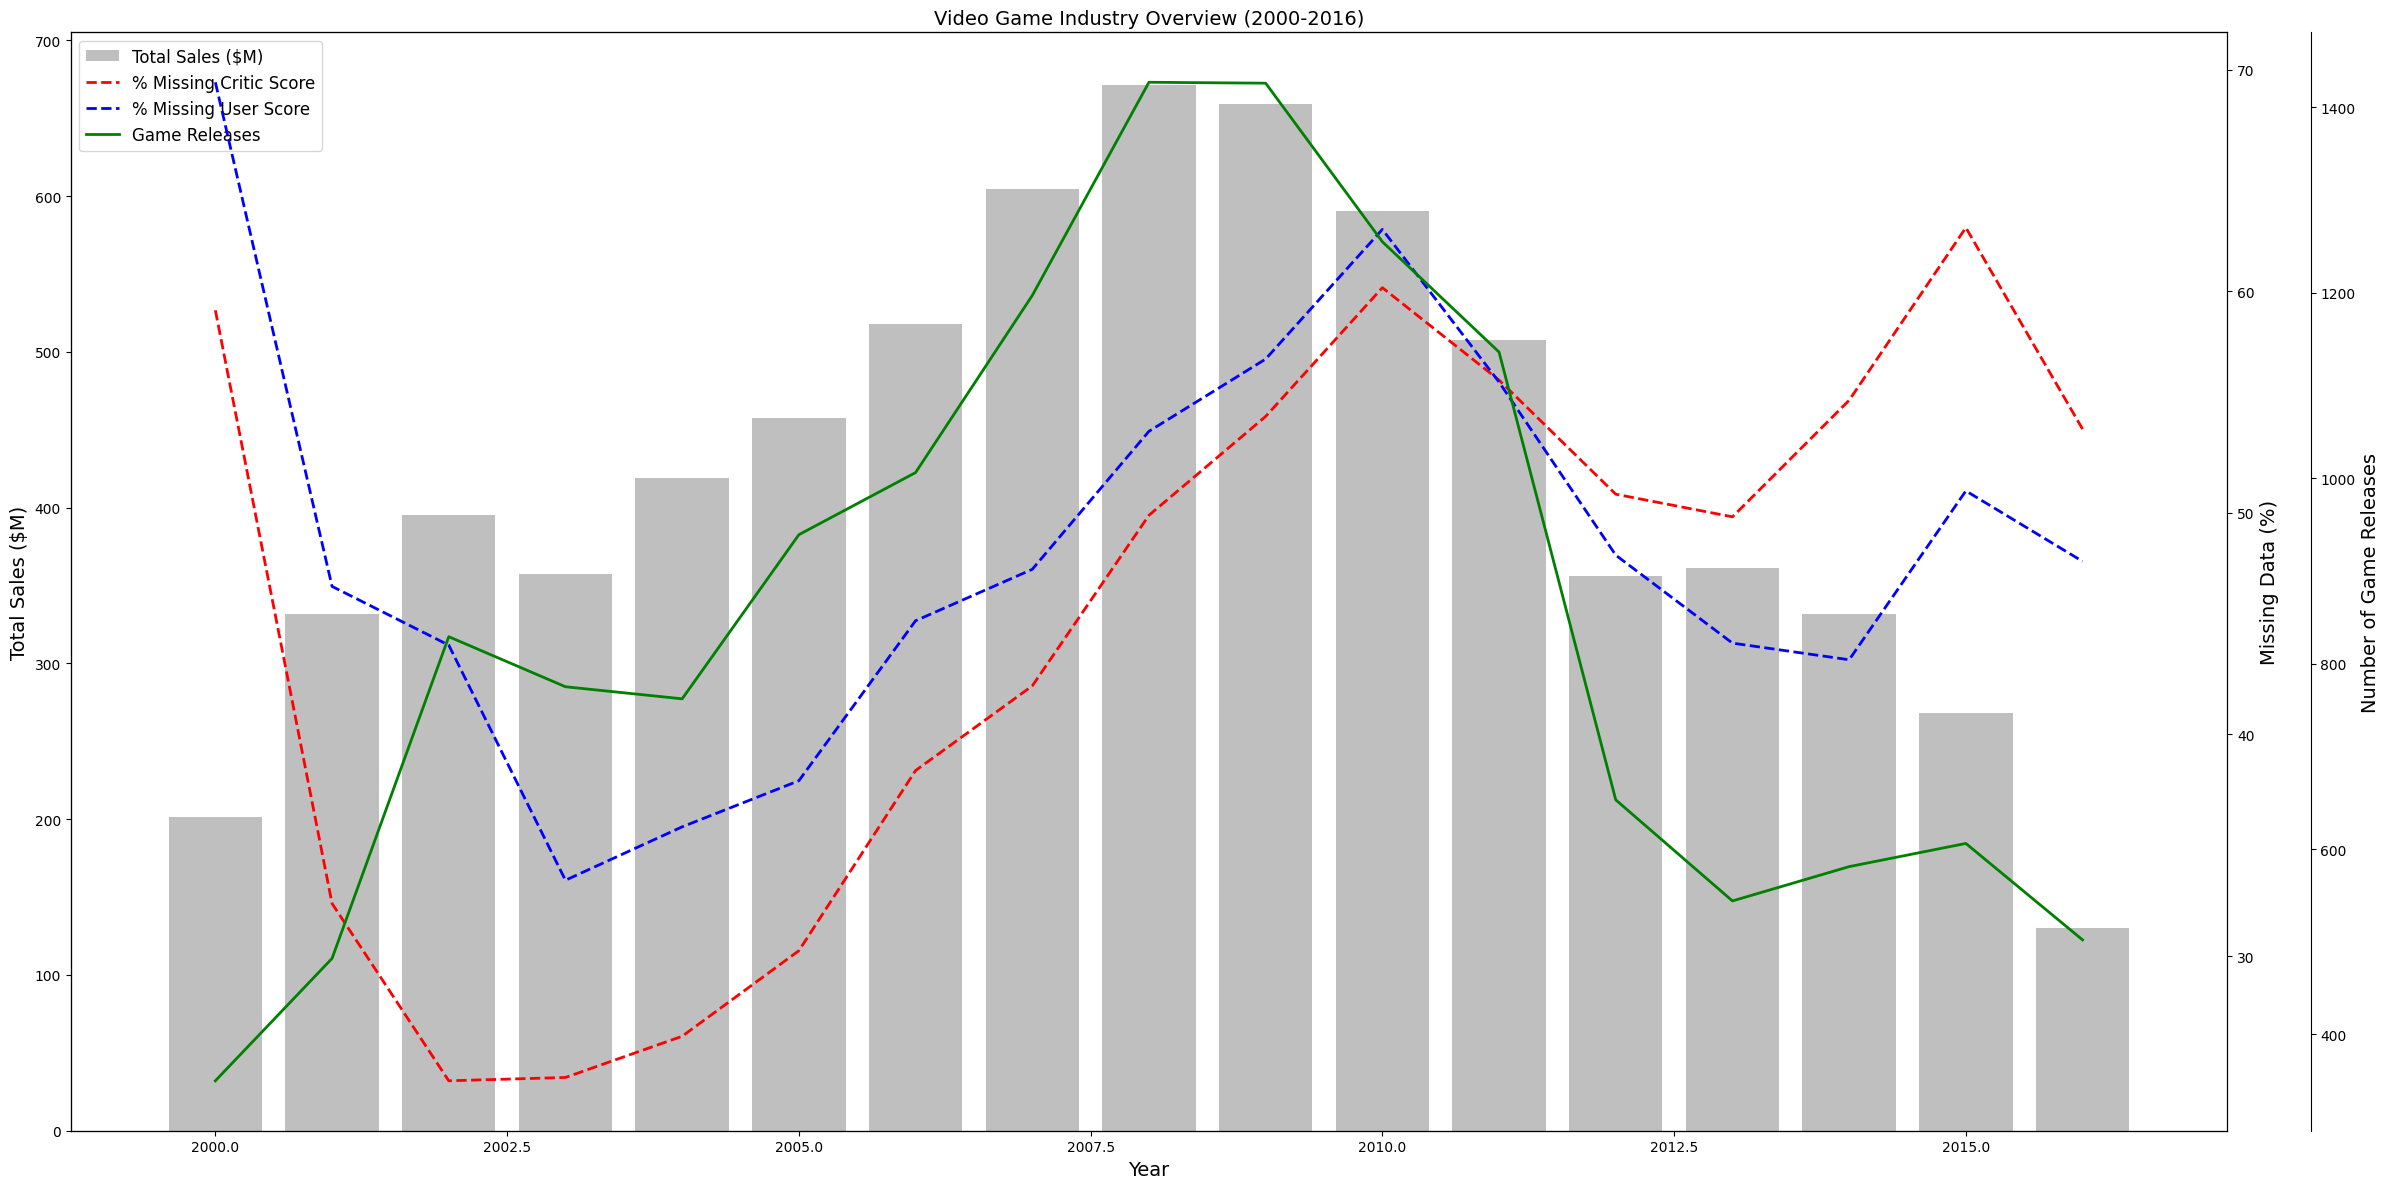

In [33]:
# Step 3: Plot triple-axis overview
# Set x-axis for years
years = sorted(annual_sales.index)

# Align the other series to the same years
sales = annual_sales.loc[years]
counts = games_count_filtered.set_index('year_of_release').loc[years, 'game_count']
missing_critic = missing_values_filtered.set_index('year_of_release').loc[years, 'critic_score']
missing_user = missing_values_filtered.set_index('year_of_release').loc[years, 'user_score']

# Plotting
fig, ax1 = plt.subplots(figsize=(24,12))

# Total Sales
ax1.bar(years, sales, color='gray', alpha=0.5, label='Total Sales ($M)')
ax1.set_ylabel('Total Sales ($M)', fontsize=14)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_title('Video Game Industry Overview (2000-2016)', fontsize=14)

# % Misssing
ax2 = ax1.twinx()
ax2.plot(years, missing_critic, color='red', label='% Missing Critic Score', linestyle='--', linewidth=2)
ax2.plot(years, missing_user, color='blue', label='% Missing User Score', linestyle='--', linewidth=2)
ax2.set_ylabel('Missing Data (%)', fontsize=14)

# Game Counts
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(years, counts, color='green', label='Game Releases', linewidth=2)
ax3.set_ylabel('Number of Game Releases', fontsize=14)

# Combine Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b> Student's Comment: </b>I have determined that the best timeframe to look at for analysis is [2001, 2002, 2003, 2004, 2005,2006, 2007, and 2013]. I came to this conclusion using by taking a look at the percentage of missing values, the number of games released per year, and the total global sales per year. For the percentage of missing values, my first thought was to use a threshold of around 30%; however, due to the large number of missing values in those two columns this left me with a total of three years to use. Feeling three years was not a large enough sample, I gradualy lowered the allowable percentage of missing value and finally settled on 50% for both 'critic_score' and 'user_score'. The other threshold I used was related to total global sales, which I felt anything less than $250M in global sales would not represent a strong enough pool. Using these thresholds I came up with the years above.
    The data shows that the market peaked around 2008, but this poses a problem. How can we create a viable hypothesis on what the market is going to do for video game sales using data that is at a minimum 5yrs old and at a maxime 16yrs old. From my experience this doesn't show the outside impacts from things like the economy, the predicted release of new game systems, and the upturn in cost of new game systems. If I utilize the 2001-2007 timeframe the information provided will be lost to the passage of time. I would normally look at the most recent 5-8yrs (2008-2016) or set up a rolling year-based validation. However, given the data I think it is smarter to use the 2001-2007 while using 2013 to augment for recency. This is based on (1) Data Quality: from 2008-2016 the percentage of missing values in the 'critic_score' fluctuates from 50% to around 63% and the 'user_score' fluctuates from 43% to 50%, (2) Market Stability: from 2008-2016 the total global sales dropped by 80% from $671M to around $130M, (3) Game Release Stability: from 2008-2016 the number of game releases had a negative change of 64.82%. All of these factors makes it extremely difficult to be able to use the data either due to large percentages of missing values that would require me to impute values to subsitute (creating a large number of artificially created values), or volatility of the market making it hard to truly train a stable predictive model, or the affect of temporal noise due to the lack of game releases from 2008-2016.
    The 2001-2007, 2013 data is statistically sound with less than 50% missing values...which will result in less imputed values. The greater than $250M in total global sales shows the video game market was stable as it moved from 5th generation consoles to 7th generation consoles. And finally, the consistent volume of game releases would equal stronger training data for predictive modeling.
    These are the Pros and Cons to why I chose to use the timefram of 2001-2007 and 2013 as my relevant years over a more recent sample of 2008-2016.
</div>

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [34]:
# Filtering DF to include only relevant years of 2001-2007 & 2013
relevant_years = [2013, 2014, 2015, 2016]
games_filtered = games[games['year_of_release'].isin(relevant_years)]
games_count_filtered = yearly_count[yearly_count['year_of_release'].isin(relevant_years)]
missing_values_filtered = (
    null_by_year[null_by_year.index.isin(relevant_years)]
    .reset_index()[['year_of_release', 'critic_score', 'user_score']]
)

games_filtered['platform'] = games_filtered['platform'].cat.remove_unused_categories()

/tmp/ipykernel_106/1238423363.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_filtered['platform'] = games_filtered['platform'].cat.remove_unused_categories()


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v2</b>
 
Everything is correct! Data has been filtered correctly, as we want to evaluate only recent trends. 

In [35]:
# Analyze platform sales trends
platform_yearly_sales = games_filtered.groupby(['year_of_release', 'platform'], observed=False)['total_sales'].sum().reset_index()

platform_grp_sales = games_filtered.groupby(['platform'], observed=False)['total_sales'].sum().reset_index()

platform_sales_genre = games_filtered.groupby(['platform', 'genre'], observed=False)['total_sales'].sum().reset_index()

In [36]:
# Sort platforms by total sales
plat_yearly_sales_sorted = platform_yearly_sales.sort_values(by='total_sales', ascending=False)
plat_grp_sales_sorted = platform_grp_sales.sort_values(by='total_sales', ascending=False)
plat_sales_genre_sorted = platform_sales_genre.sort_values(by='total_sales', ascending=False)

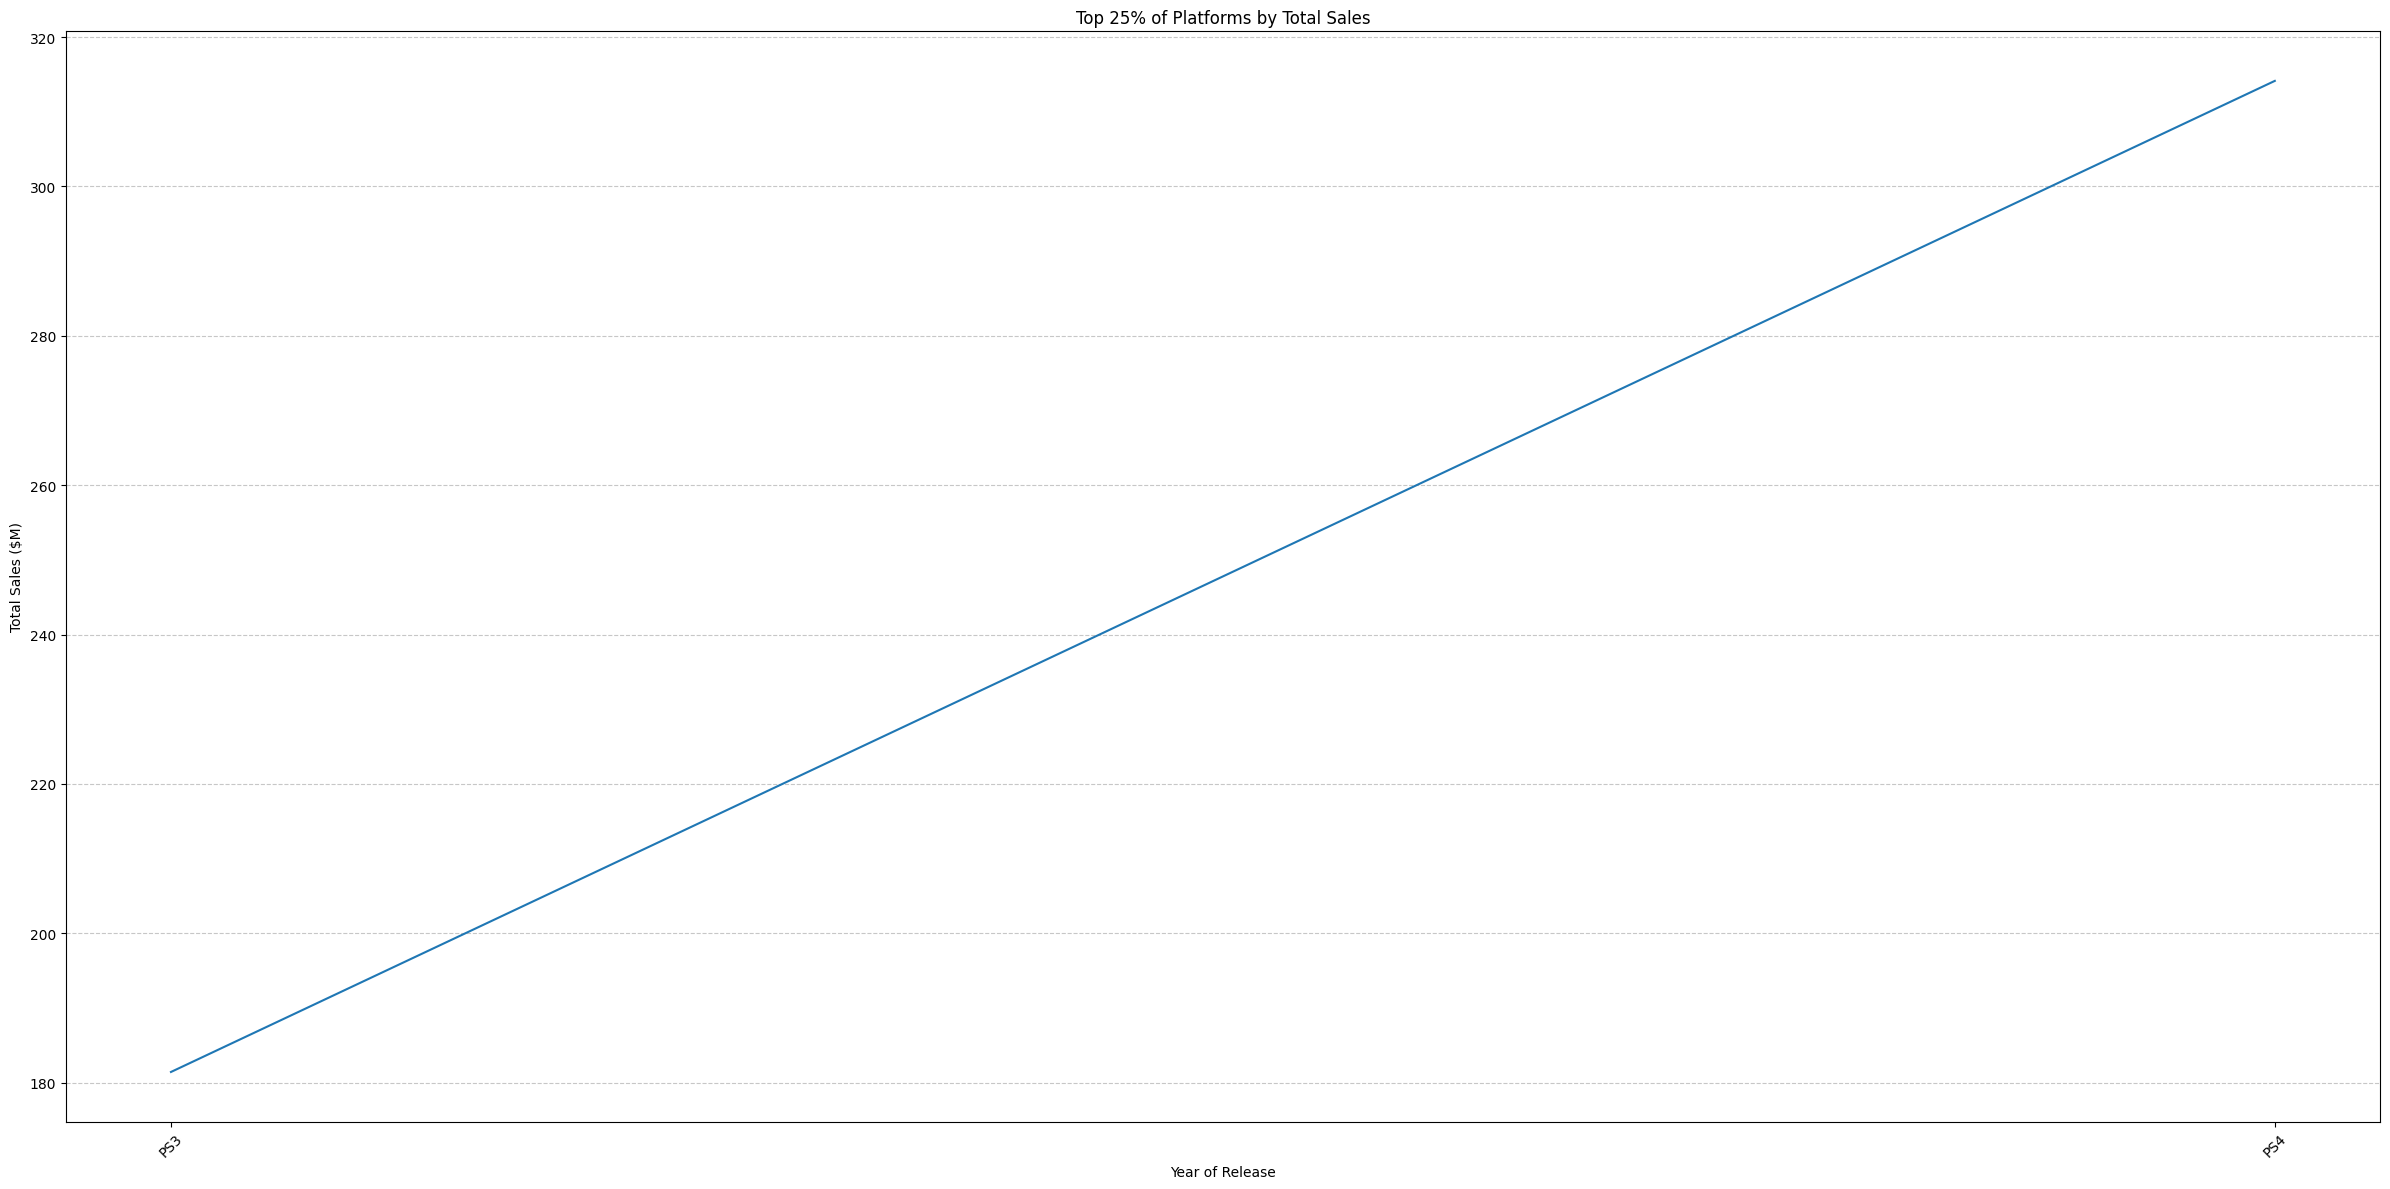

In [37]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates
# Calculating the top 10 platforms by total sales
top_10_platforms = plat_grp_sales_sorted.head(int(len(plat_grp_sales_sorted)
                                               * 0.25))
# Visualizing the top platforms by total sales
plt.figure(figsize=[24,12])
sns.lineplot(data=top_10_platforms, x='platform', y='total_sales')
plt.title('Top 25% of Platforms by Total Sales')
plt.xlabel('Year of Release')
plt.ylabel('Total Sales ($M)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


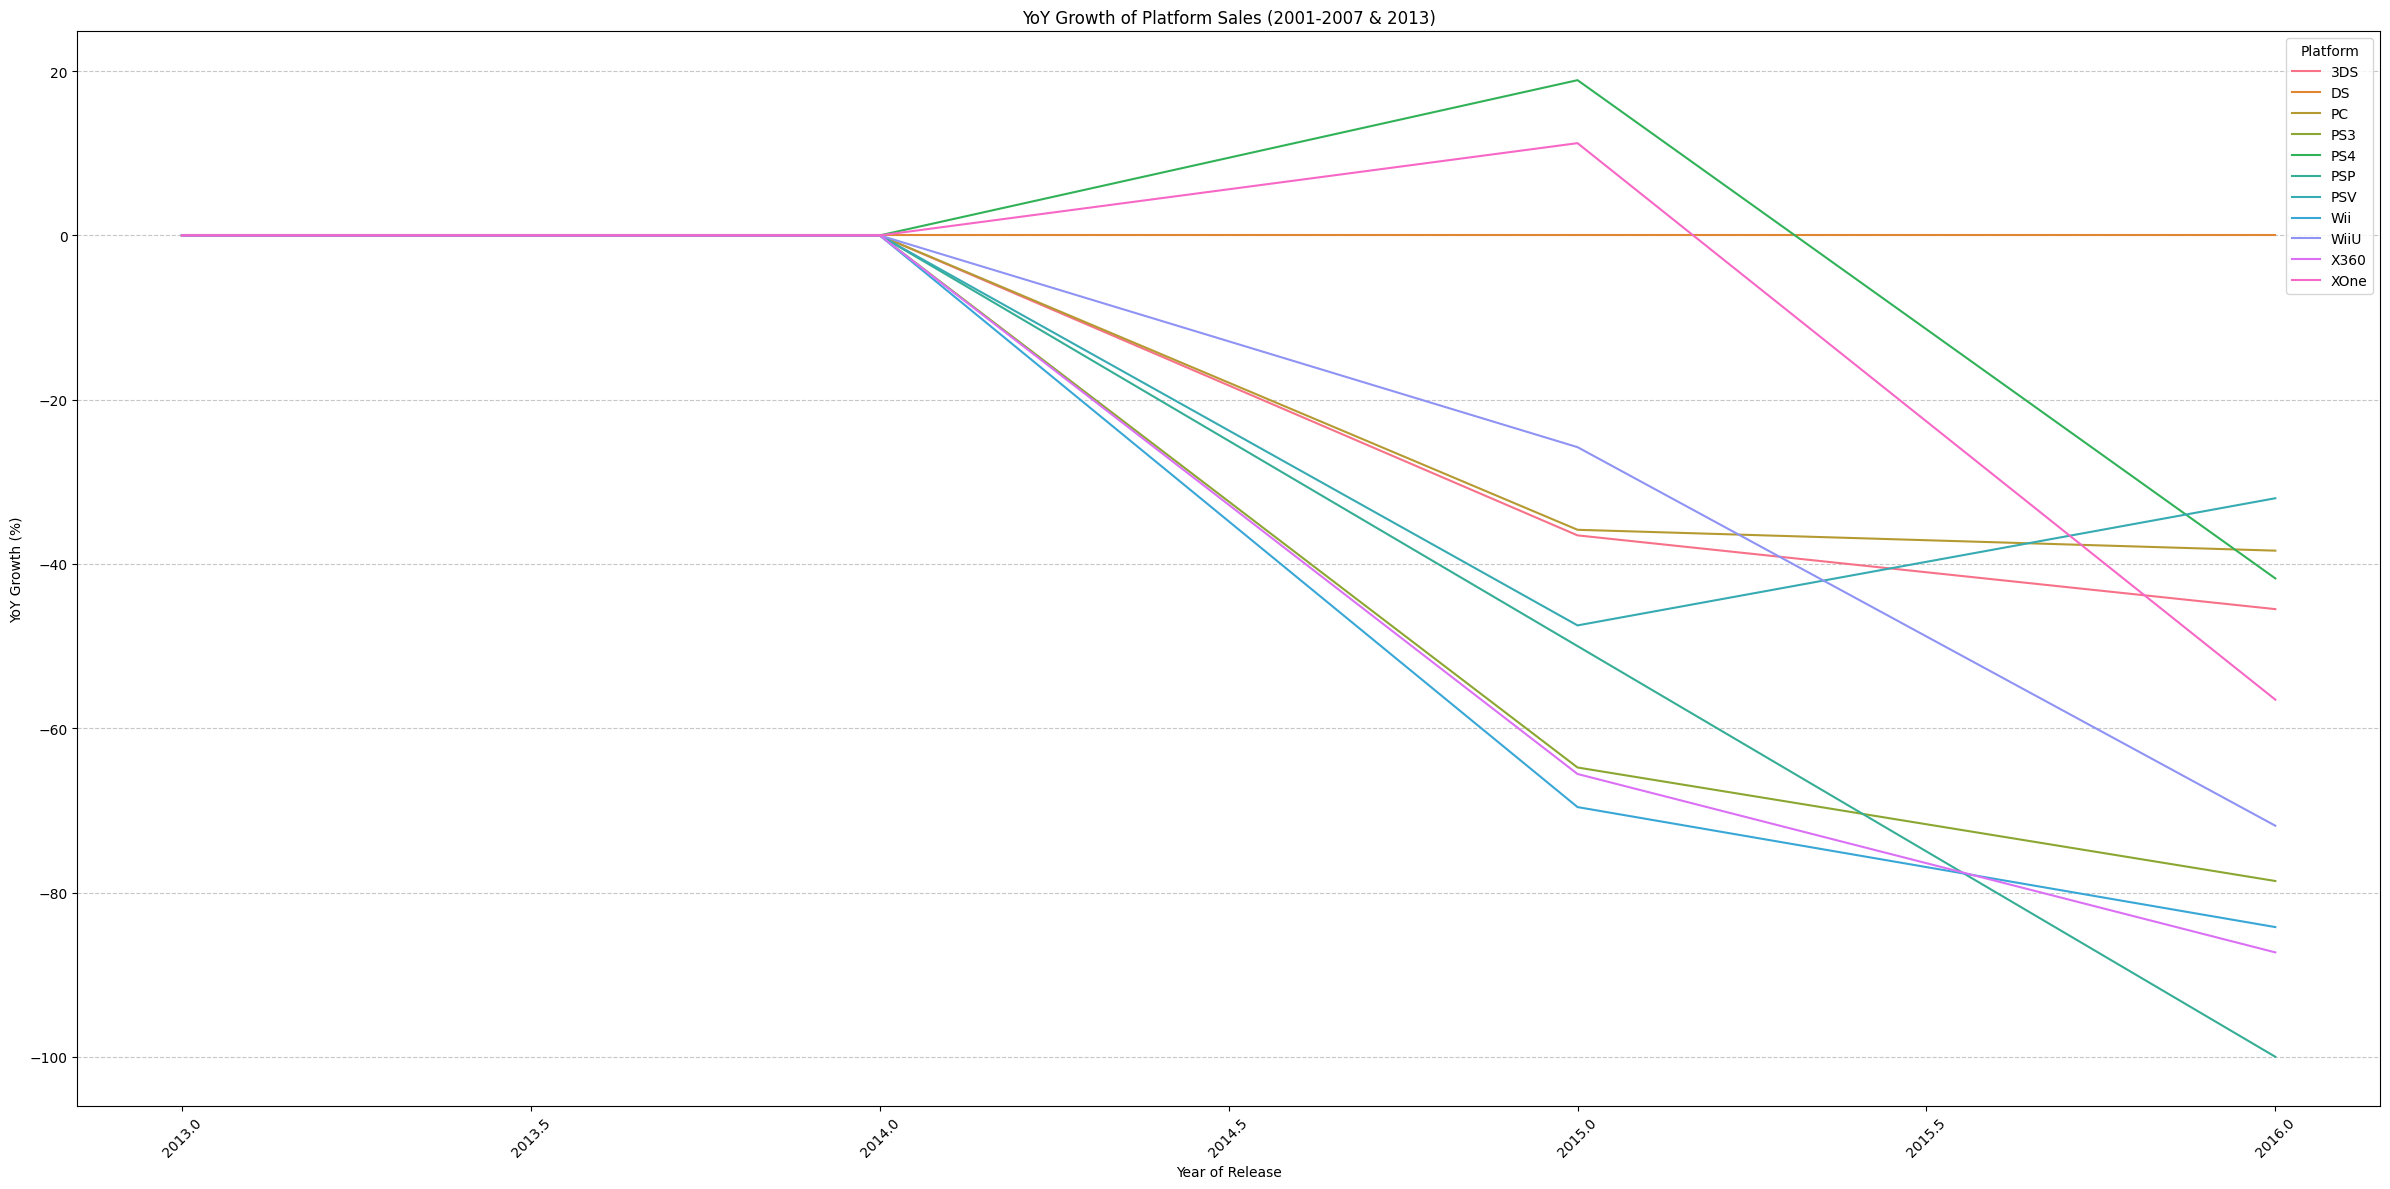

In [38]:
# Calculate Year-over-Year (YoY) growth for each platform
platform_yoy_growth = platform_yearly_sales.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    observed=False
).pct_change() * 100
# clean rounding
platform_yoy_growth = platform_yoy_growth.round(2)
# For loop to ignore the .pct_change() for the first year of a platform release
for col in platform_yoy_growth.columns:
    first_valid_index = platform_yoy_growth[col].first_valid_index()
    if first_valid_index is not None:
        platform_yoy_growth.loc[first_valid_index, col] = np.nan

platform_yoy_growth = platform_yoy_growth.fillna(0)

# Plotting the YoY growth for each platform
plt.figure(figsize=[24,12])
sns.lineplot(data=platform_yoy_growth, dashes=False)
plt.title('YoY Growth of Platform Sales (2001-2007 & 2013)')
plt.xlabel('Year of Release')
plt.ylabel('YoY Growth (%)')
plt.xticks(rotation=45)
plt.legend(title='Platform')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

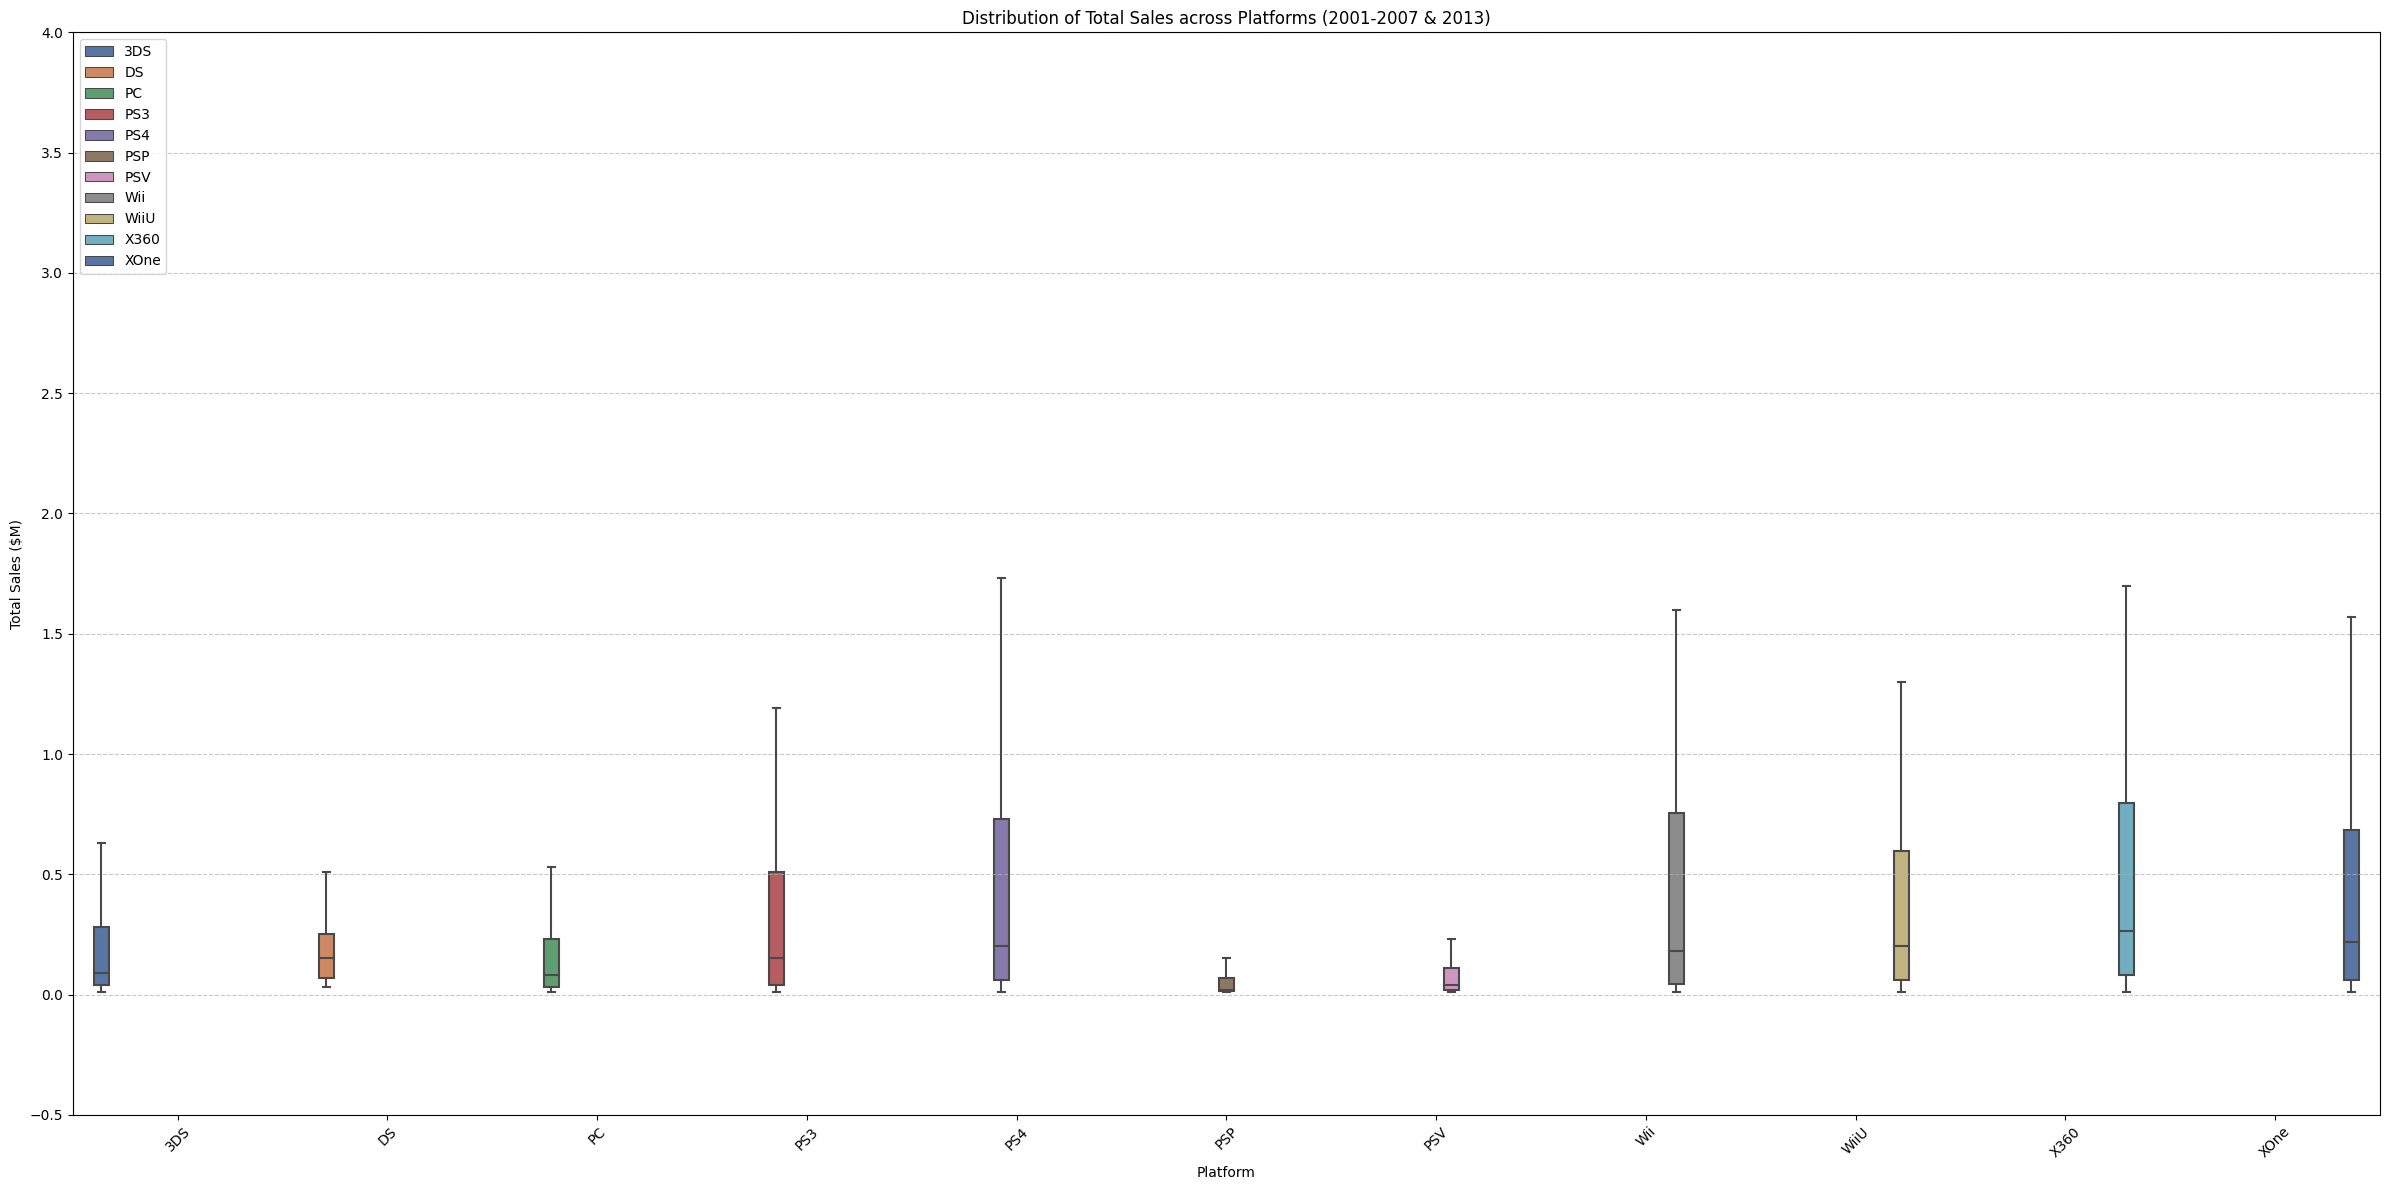

In [39]:
# Create box plot of sales by platform
plt.figure(figsize=[24,12])
sns.boxplot(data=games_filtered,
            x='platform',
            y='total_sales',
            hue='platform',
            palette='deep',
            showfliers=False
            )
plt.title('Distribution of Total Sales across Platforms (2001-2007 & 2013)')
plt.xlabel('Platform')
plt.ylabel('Total Sales ($M)')
plt.ylim(-0.5, 4),
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
    
<b>Reviewer's comment v1:</b>

To remove outliers from the box plot, set `showfliers=False in sns.boxplot`.
This hides the individual points that represent outliers, making the plot cleaner and easier to interpret.

```python
sns.boxplot(x='platform', y='total_sales', data=games_df, palette="coolwarm", showfliers=False)
```

In [40]:
# Calculate detailed statistics for each platform
# Step 1: Group by platform, calculate total sales, call .describe() to get summary statistics, then finally round the results to 2 decimal places
platform_stats = games_filtered.groupby('platform', observed=False)['total_sales'].describe().round(2)
# Step 2: Calculate the variance for each platform
platform_variance = games_filtered.groupby('platform', observed=False)['total_sales'].var().round(2)
# Step 3: Add the variance to the platform_stats DataFrame
platform_stats['variance'] = platform_variance
# Step 4: Calculate the coefficient of variation (CV) for each platform
cv_platform = (platform_stats['std'] / platform_stats['mean'] * 100).round(2)
# Step 5: Add the CV to the platform_stats DataFrame
platform_stats['CV'] = cv_platform
# Step 6: Sort the DataFrame by CV in ascending order
platform_stats = platform_stats.sort_values(by='CV', ascending=True)
# Step 7: Display the final platform_stats DataFrame
print(platform_stats)

          count  mean   std   min   25%   50%   75%    max  variance      CV
platform                                                                    
DS          8.0  0.19  0.17  0.03  0.07  0.15  0.25   0.51      0.03   89.47
PSP        67.0  0.05  0.06  0.01  0.02  0.02  0.07   0.24      0.00  120.00
Wii        23.0  0.59  0.92  0.01  0.04  0.18  0.76   3.58      0.84  155.93
XOne      247.0  0.65  1.04  0.01  0.06  0.22  0.68   7.39      1.07  160.00
PC        189.0  0.21  0.35  0.01  0.03  0.08  0.23   3.05      0.12  166.67
PSV       358.0  0.09  0.15  0.01  0.02  0.04  0.11   1.96      0.02  166.67
WiiU      115.0  0.56  1.04  0.01  0.06  0.20  0.60   7.09      1.08  185.71
PS4       392.0  0.80  1.61  0.01  0.06  0.20  0.73  14.63      2.59  201.25
X360      186.0  0.74  1.66  0.01  0.08  0.26  0.80  16.27      2.77  224.32
PS3       345.0  0.53  1.45  0.01  0.04  0.15  0.51  21.05      2.11  273.58
3DS       303.0  0.47  1.38  0.01  0.04  0.09  0.28  14.60      1.91  293.62

## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [41]:
# Choose a popular platform based on your previous analysis
popular_platform = 'X360'
# Filter for popular_platform
x360_sales_data = games_filtered[games_filtered['platform'] == popular_platform]

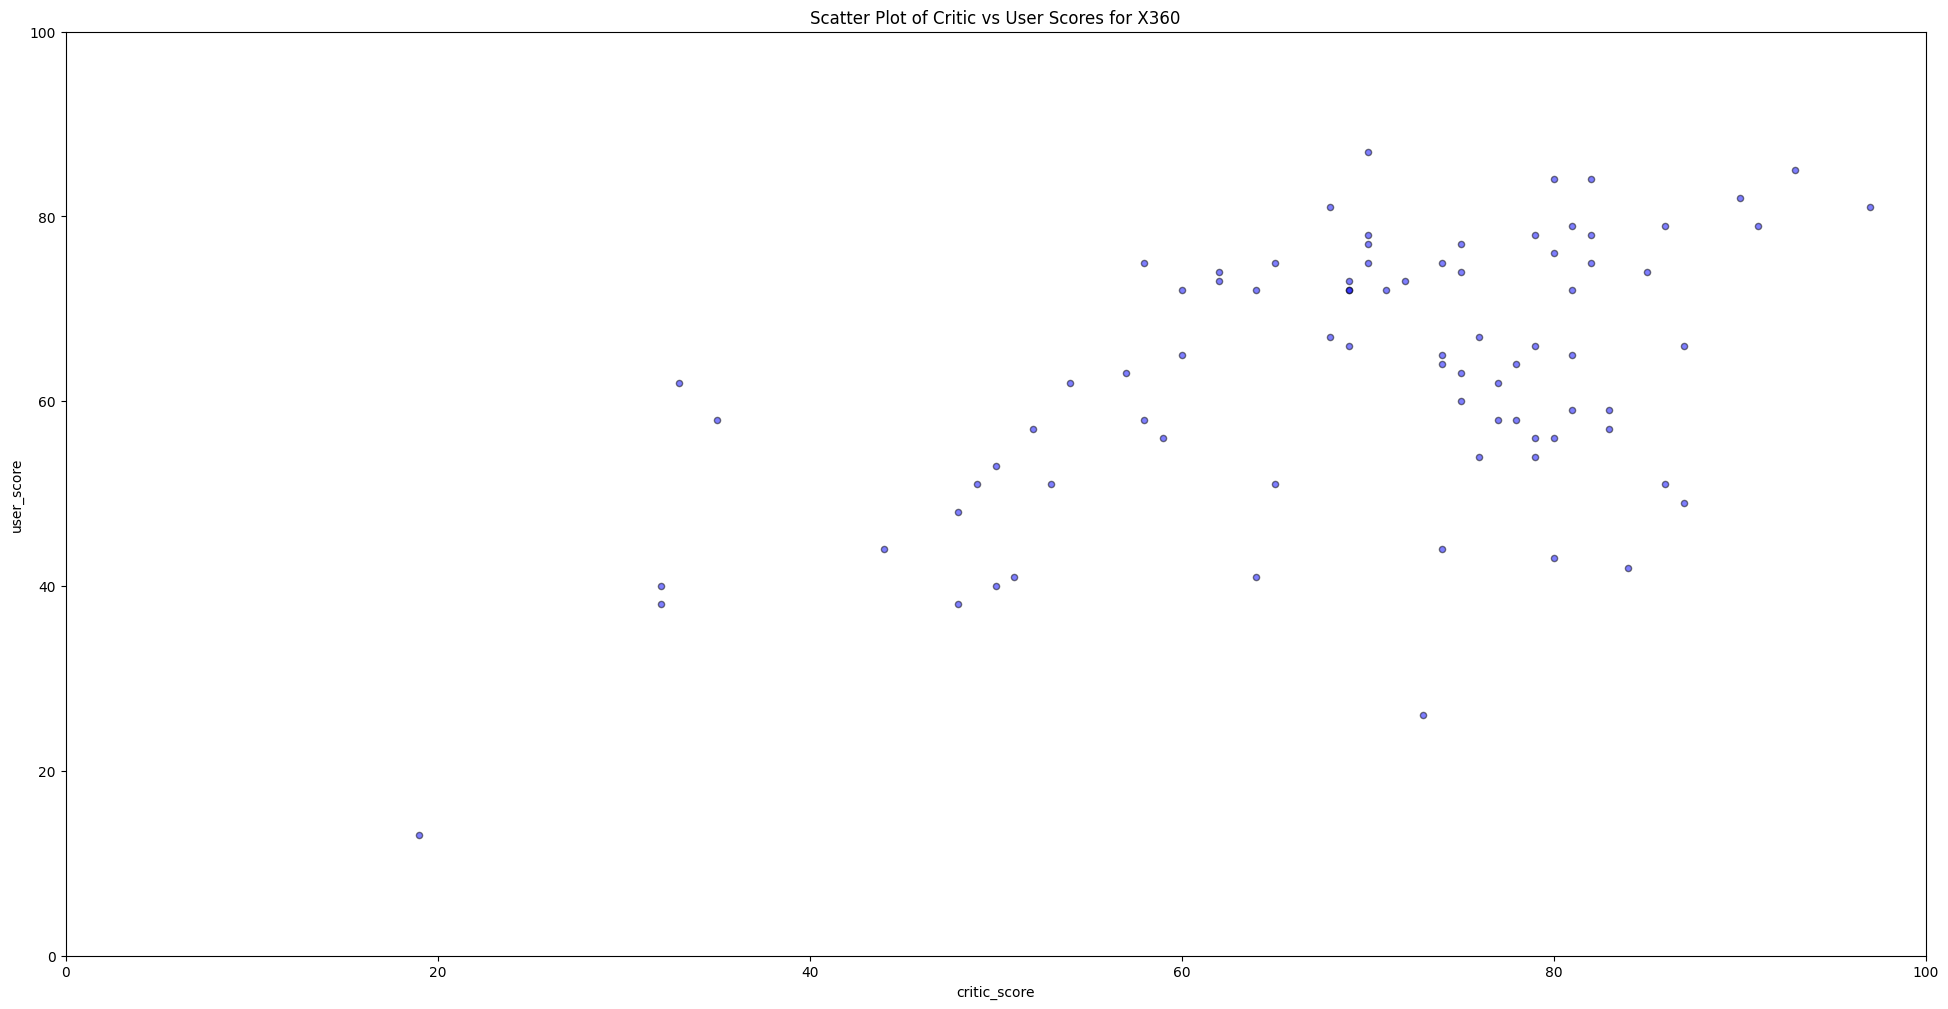

In [42]:
# Create scatter plots for both critic and user scores
x360_sales_data.plot.scatter(x='critic_score',
                             xlim=(0,100),
                             y='user_score',
                             ylim=(0,100),
                             alpha=0.5,
                             edgecolor='black',
                             color='blue',
                            figsize=[24,12],
                            title=f'Scatter Plot of Critic vs User Scores for {popular_platform}'
)
plt.show()

In [43]:
# Critic Scores
x360_critic_nan_count = x360_sales_data['critic_score'].isna().sum()

# Flags those rows where the critic score is NaN
x360_sales_data.loc[:, 'critic_score_filled'] = x360_sales_data['critic_score'].isna()

# Fill NaN values in 'critic_score' with the median of column 16.5% of column
x360_sales_data.loc[:, 'critic_score'] = x360_sales_data['critic_score'].fillna(x360_sales_data['critic_score'].median())

# Verify that all NaN values have been filled
x360_critic_nan_count_after = x360_sales_data['critic_score'].isna().sum()

# User Scores
x360_user_nan_count = x360_sales_data['user_score'].isna().sum()

# Flags those rows where the user score is NaN
x360_sales_data.loc[:, 'user_score_filled'] = x360_sales_data['user_score'].isna()

# Fill NaN values in 'user_score' with the median of column 16.5% of column
x360_sales_data.loc[:, 'user_score'] = x360_sales_data['user_score'].fillna(x360_sales_data['user_score'].median())

# Verify that all NaN values have been filled
x360_user_nan_count_after = x360_sales_data['user_score'].isna().sum()

# Calculate correlations
x360_sales_critic_score_corr = x360_sales_data[['total_sales', 'critic_score']].corr(method='pearson').round(2)
x360_sales_user_score_corr = x360_sales_data[['total_sales', 'user_score']].corr(method='pearson').round(2)

print(f'Correlation between Total Sales and Critic Score for {popular_platform}: {x360_sales_critic_score_corr}')

print(f'Correlation between Total Sales and User Score for {popular_platform}: {x360_sales_user_score_corr}')


Correlation between Total Sales and Critic Score for X360:               total_sales  critic_score
total_sales          1.00          0.26
critic_score         0.26          1.00
Correlation between Total Sales and User Score for X360:              total_sales  user_score
total_sales         1.00       -0.02
user_score         -0.02        1.00


/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [44]:
# Is there a correlation between the 'critic_score' and 'user_score' and if a game is a hit or a flop?
# Step 1: Define a hit as a game with total sales greater than 1 million
hit_threshold = 1.0

# Step 2: Create a categorical column 'hit_or_flop' based on the hit_threshold
for row in x360_sales_data.itertuples():
    if row.total_sales >= hit_threshold:
        x360_sales_data.loc[row.Index, 'hit_or_flop'] = 'Hit'
    else:
        x360_sales_data.loc[row.Index, 'hit_or_flop'] = 'Flop'

# Step 3: Calculate the Correlation between 'critic_score' and 'user_score' and whether a game is a hit or a flop
x360_sales_data['hit_or_flop_numeric'] = x360_sales_data['hit_or_flop'].map({'Flop': 0, 'Hit': 1})
x360_hit_flop_corr = x360_sales_data[['critic_score', 'user_score', 'hit_or_flop_numeric']].corr(method='pearson').round(2)
print(f'Correlation between Critic Score, User Score, and Hit/Flop for {popular_platform}:')
print(x360_hit_flop_corr)

Correlation between Critic Score, User Score, and Hit/Flop for X360:
                     critic_score  user_score  hit_or_flop_numeric
critic_score                 1.00        0.31                 0.27
user_score                   0.31        1.00                -0.02
hit_or_flop_numeric          0.27       -0.02                 1.00


/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1599: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
/tmp/ipykernel_106/2109405394.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>Taking a look at the Xbox 360 data for the time period of 2001-2007 & 2013, it is clear that the 'total_sales' of a game does not have a correlated affect on the 'critic_score' or 'user_score'. However, if you use $1M in sales as the threshold to whether a video game is a "Hit" or a "Flop", then there is a slight correlation that the 'critic_score' can have an affect on the 'total_sales'
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Well done! Very nice scatter plots.


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>
QUESTION FOR MY REVIEWER: I struggled with this section. To be honest, I couldn't understand the value in comparing just sales performance for games with multi-platform releases. The best I could figure out (with help from a tutor) was to graph out the sales per platform for each of the top 5 games on it's own bar graph. But even after that, I still struggle to see a correlation in this. Can you help me understand it's purpose a bit better?
</div>

In [45]:
# Find games released on multiple platforms
cross_platform_games = games_filtered.groupby('name', observed=False).filter(lambda x: len(x) > 1)
# Step 1: Create a DataFrame with the count of platforms per game
cross_platform_counts = cross_platform_games.groupby('name', observed=False)['platform'].nunique().reset_index()
cross_platform_counts = cross_platform_counts.rename(columns={'platform': 'platform_count'})
# Step 2: Merge the cross_platform_counts with the original games_filtered DataFrame
cross_platform_games = cross_platform_games.merge(cross_platform_counts, on='name', how='left')
# Step 3: Filter for games released on multiple platforms
cross_platform_games = cross_platform_games[cross_platform_games['platform_count'] > 1].sort_values(by='name', ascending=True)

print(f'Number of games released on multiple platforms: {len(cross_platform_games)}')
print(cross_platform_games.head())

Number of games released on multiple platforms: 1443
                                  name platform  year_of_release  \
323               Frozen: Olaf's Quest      3DS             2013   
367               Frozen: Olaf's Quest       DS             2013   
419         2014 FIFA World Cup Brazil     X360             2014   
313         2014 FIFA World Cup Brazil      PS3             2014   
683  3rd Super Robot Wars Z Jigoku Hen      PSV             2014   

            genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
323      Platform      0.27      0.27      0.00         0.05           NaN   
367      Platform      0.21      0.26      0.00         0.04           NaN   
419        Sports      0.15      0.25      0.00         0.03          74.0   
313        Sports      0.15      0.36      0.01         0.09          73.0   
683  Role-Playing      0.00      0.00      0.19         0.00           NaN   

     user_score   rating  total_sales  platform_count  
323         N

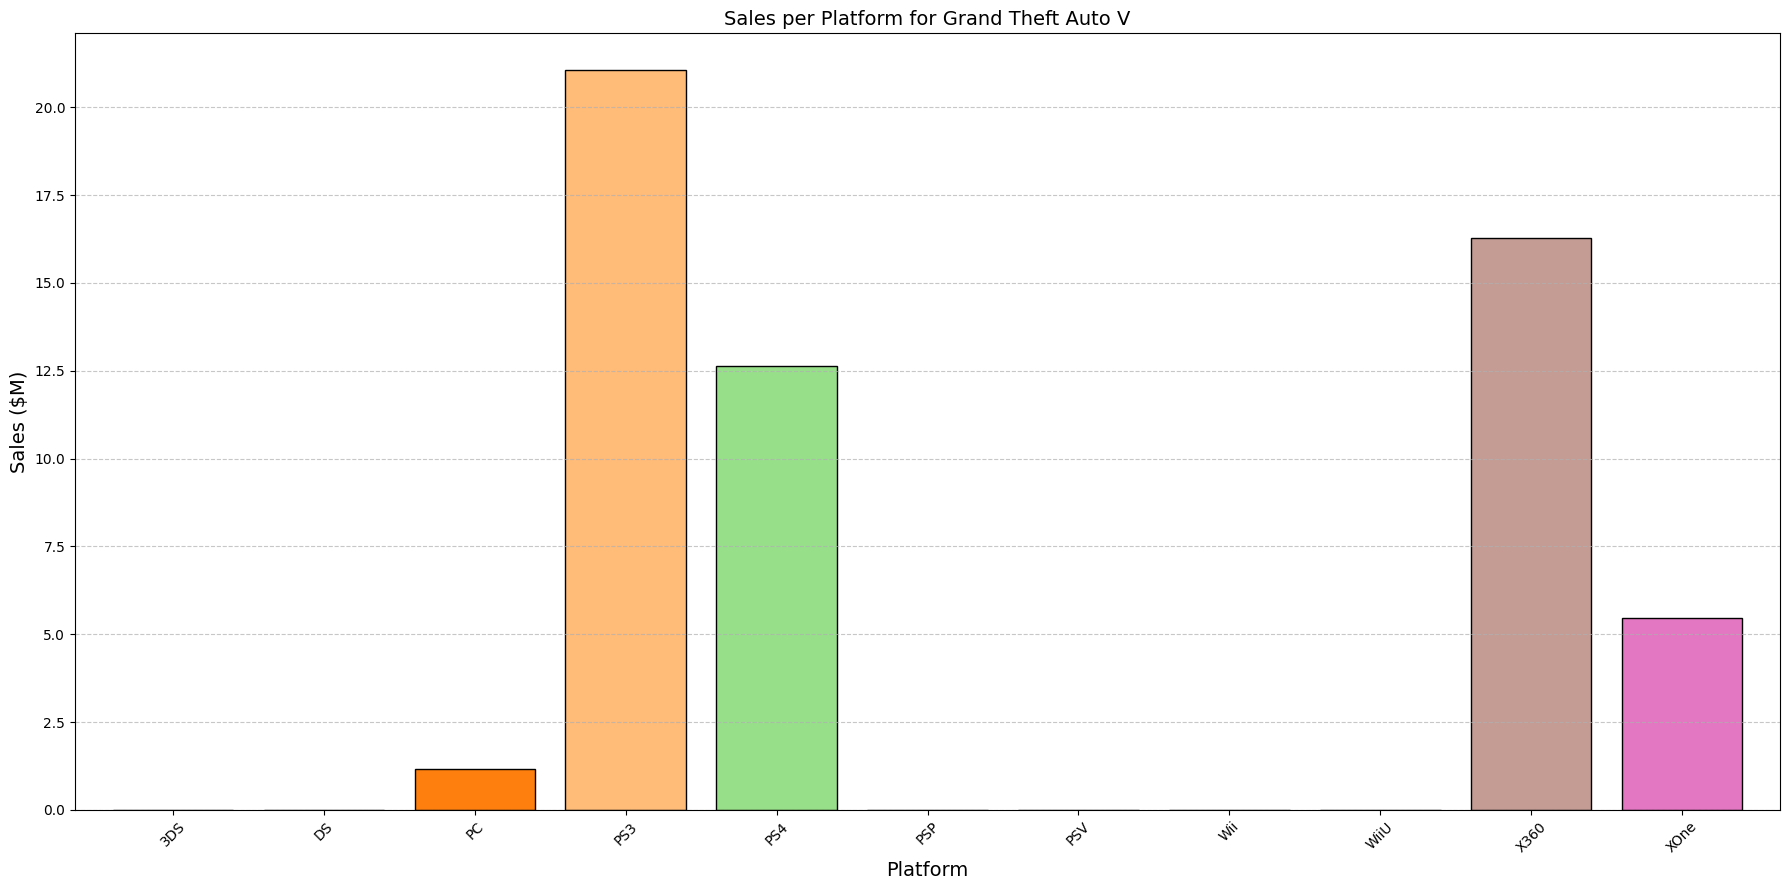

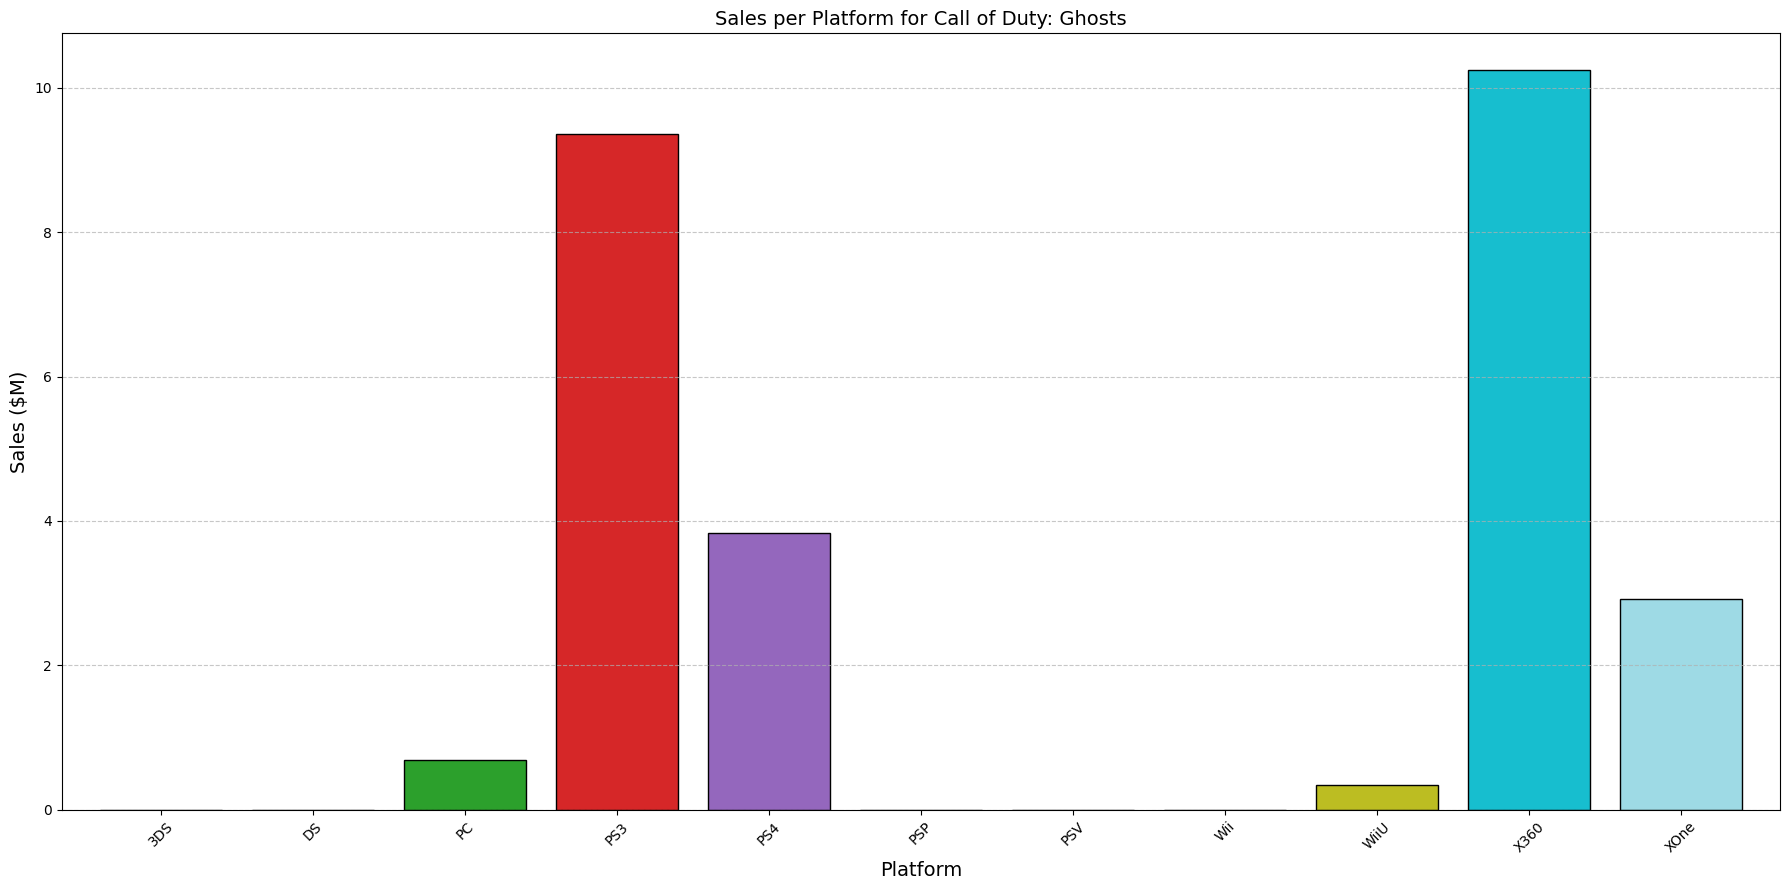

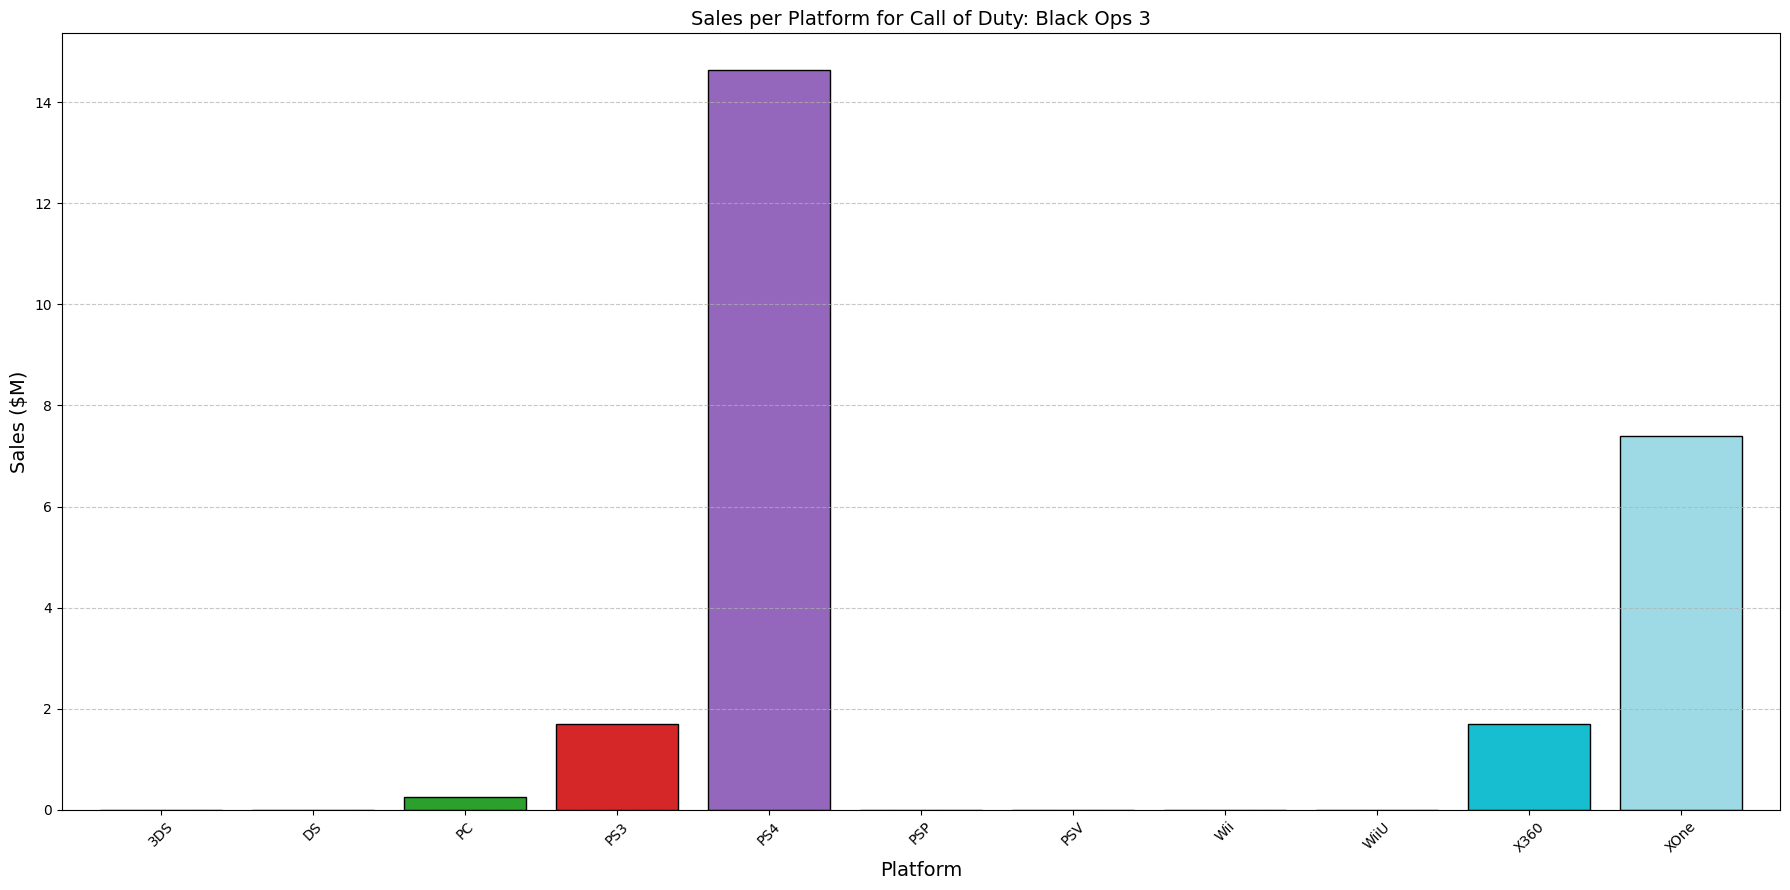

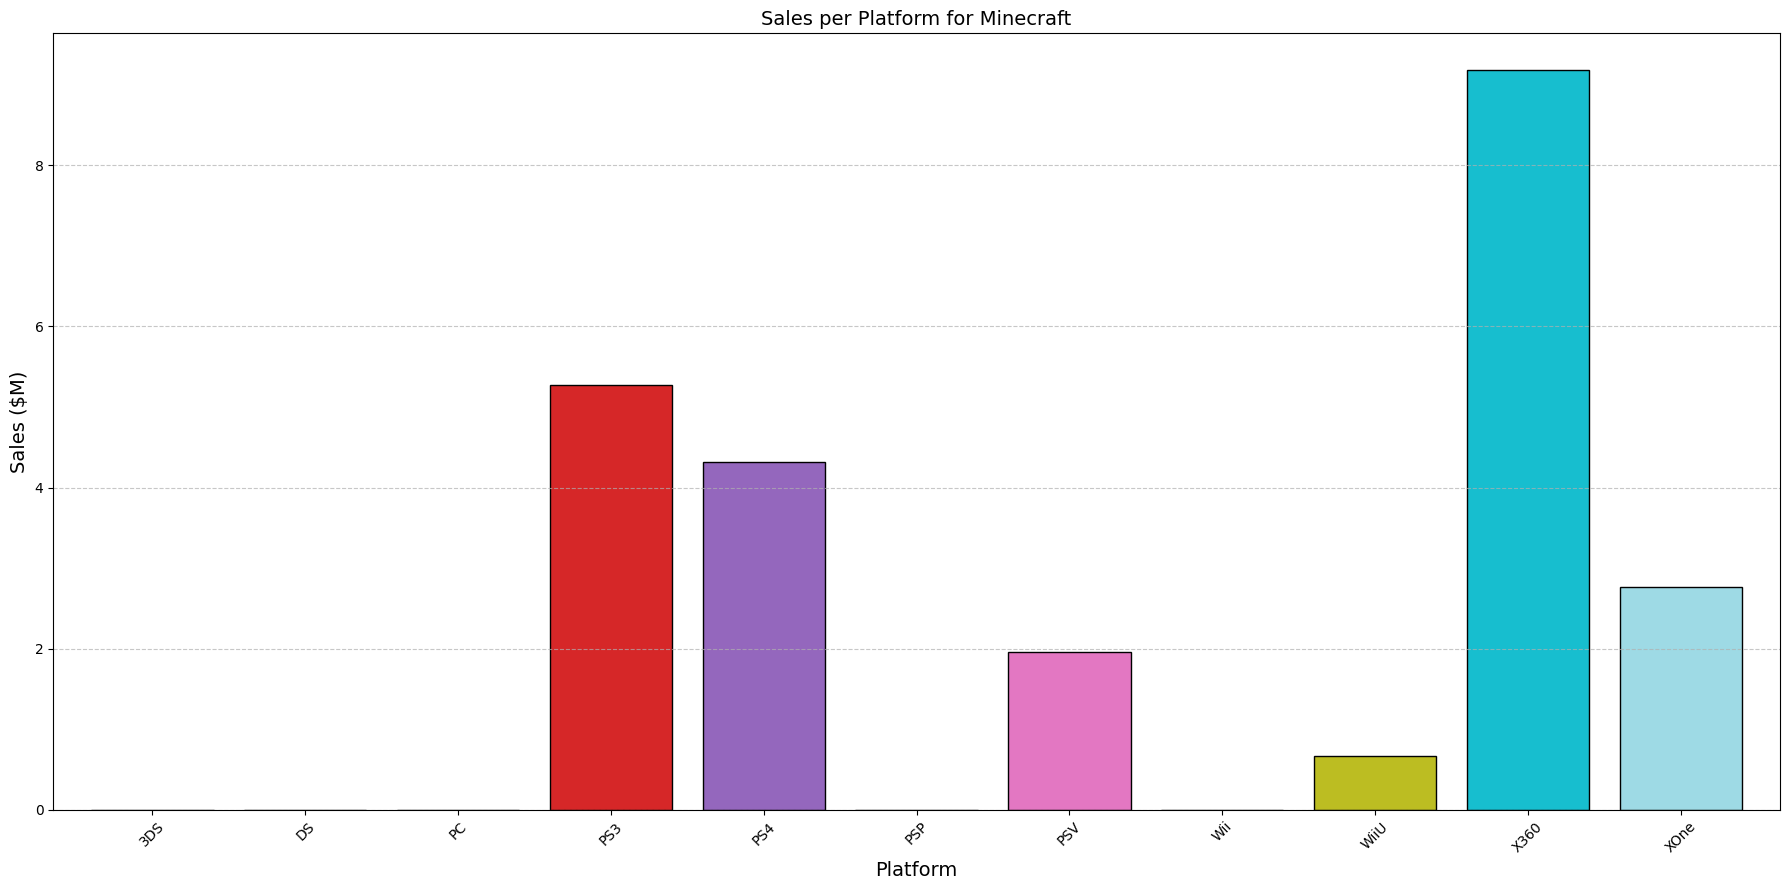

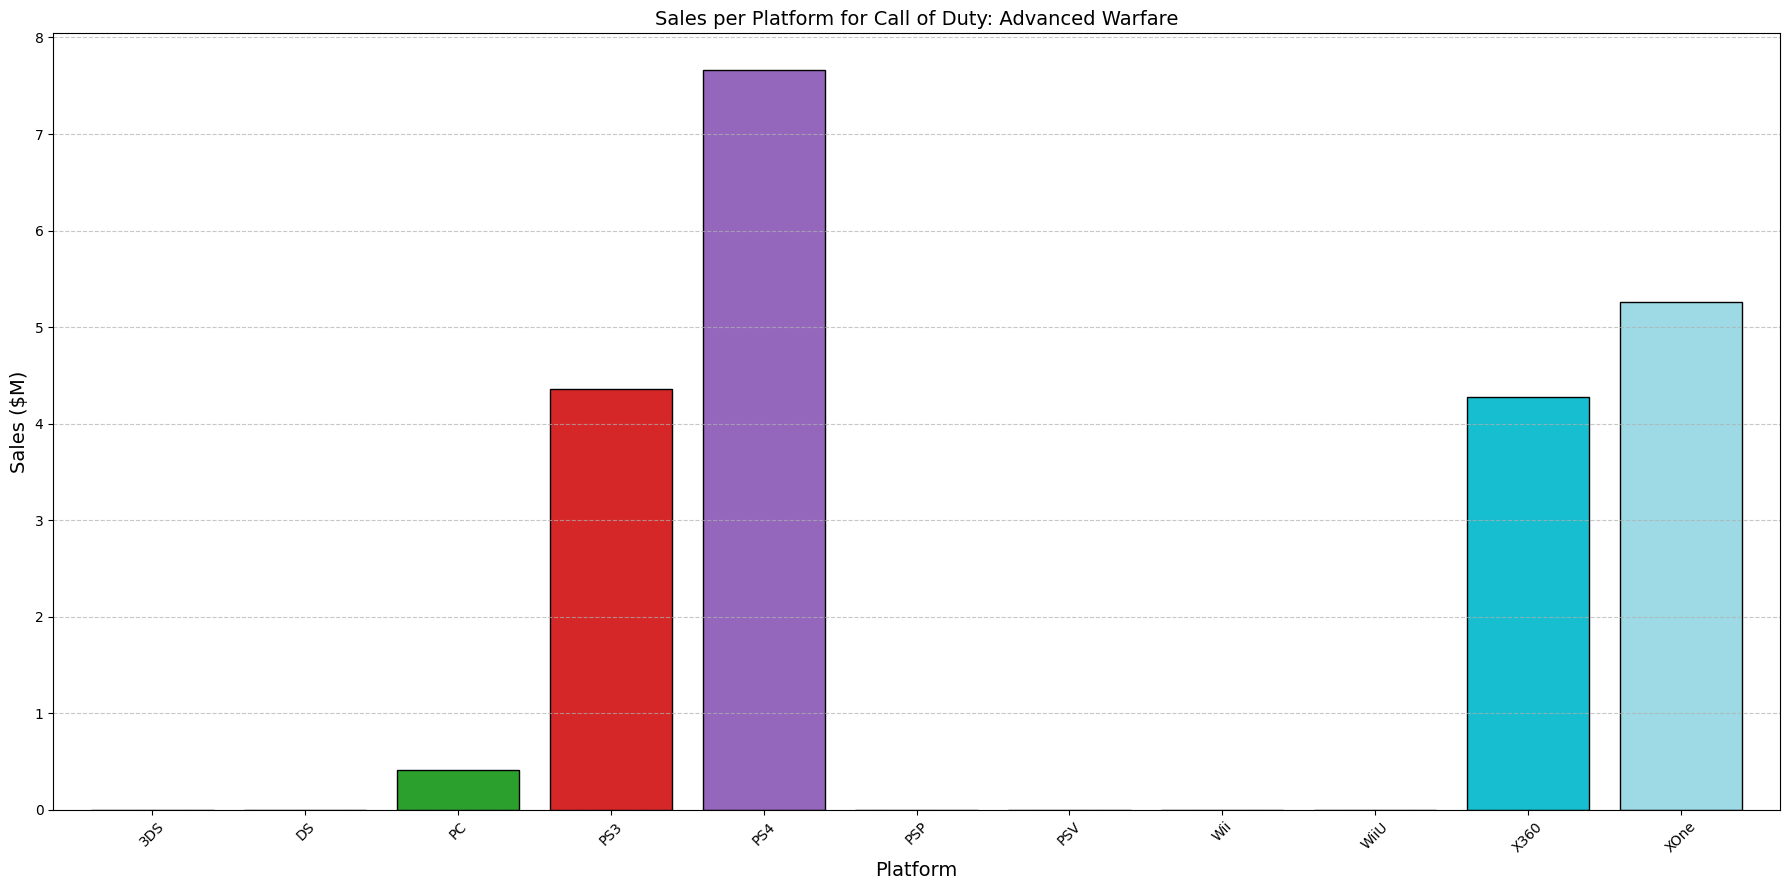

In [46]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance
# Step 1: Create a pivot table to compare sales across platforms for cross-platform games
cross_platform_sales = cross_platform_games.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)
# Step 2: Calculate the total sales for each game across all platforms
cross_platform_sales.columns = cross_platform_sales.columns.astype(str)
cross_platform_sales['total_sales'] = cross_platform_sales.sum(axis=1)
cross_platform_sales = cross_platform_sales.sort_values(by='total_sales', ascending=False
)
# Step 3: Determine the top 5 games by total sales across all platforms
top_5_cross_platform_games = cross_platform_sales.head(5)
#print(top_5_cross_platform_games)

# Step 4: Visualize the top 5 cross-platform games
for game in top_5_cross_platform_games.index:
    plt.figure(figsize=[18,9])
    cmap = plt.get_cmap('tab20')
    colors = cmap(np.linspace(0,1, len(sales)))

    #extract the sales data for the current game
    sales = top_5_cross_platform_games.loc[game].drop('total_sales')

    #Create a bar chart
    sales.plot(kind='bar', color=colors, edgecolor='black', width=0.8)

    #formatting the chart
    plt.title(f'Sales per Platform for {game}', fontsize=14)
    plt.ylabel('Sales ($M)', fontsize=14)
    plt.xlabel('Platform', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>
BEGINNING THOUGHTS: I first started by asking the quesion "How do we measure performance?" Of course the most common way is by total global sales; however, when I really think about performance by genre...I come up with a few other areas. (1) Does a Critic's score affect a specific genre? What about a User's score? (2) Is there a genre that gets more reviews than others? (3) Is a genre's performance affected by the platform?
</div>

In [47]:
# Analyze genre performance
# Group by genre and calculate total sales
genre_sales = games_filtered.groupby('genre', observed=False)['total_sales'].sum().reset_index()

In [48]:
# Sort genres by total sales
genre_sales = genre_sales.sort_values(by='total_sales', ascending=False)

print(genre_sales)

           genre  total_sales
0         Action       321.87
8        Shooter       232.98
10        Sports       150.65
7   Role-Playing       145.89
3           Misc        62.82
4       Platform        42.63
6         Racing        39.89
2       Fighting        35.31
1      Adventure        23.64
9     Simulation        21.76
11      Strategy        10.08
5         Puzzle         3.17


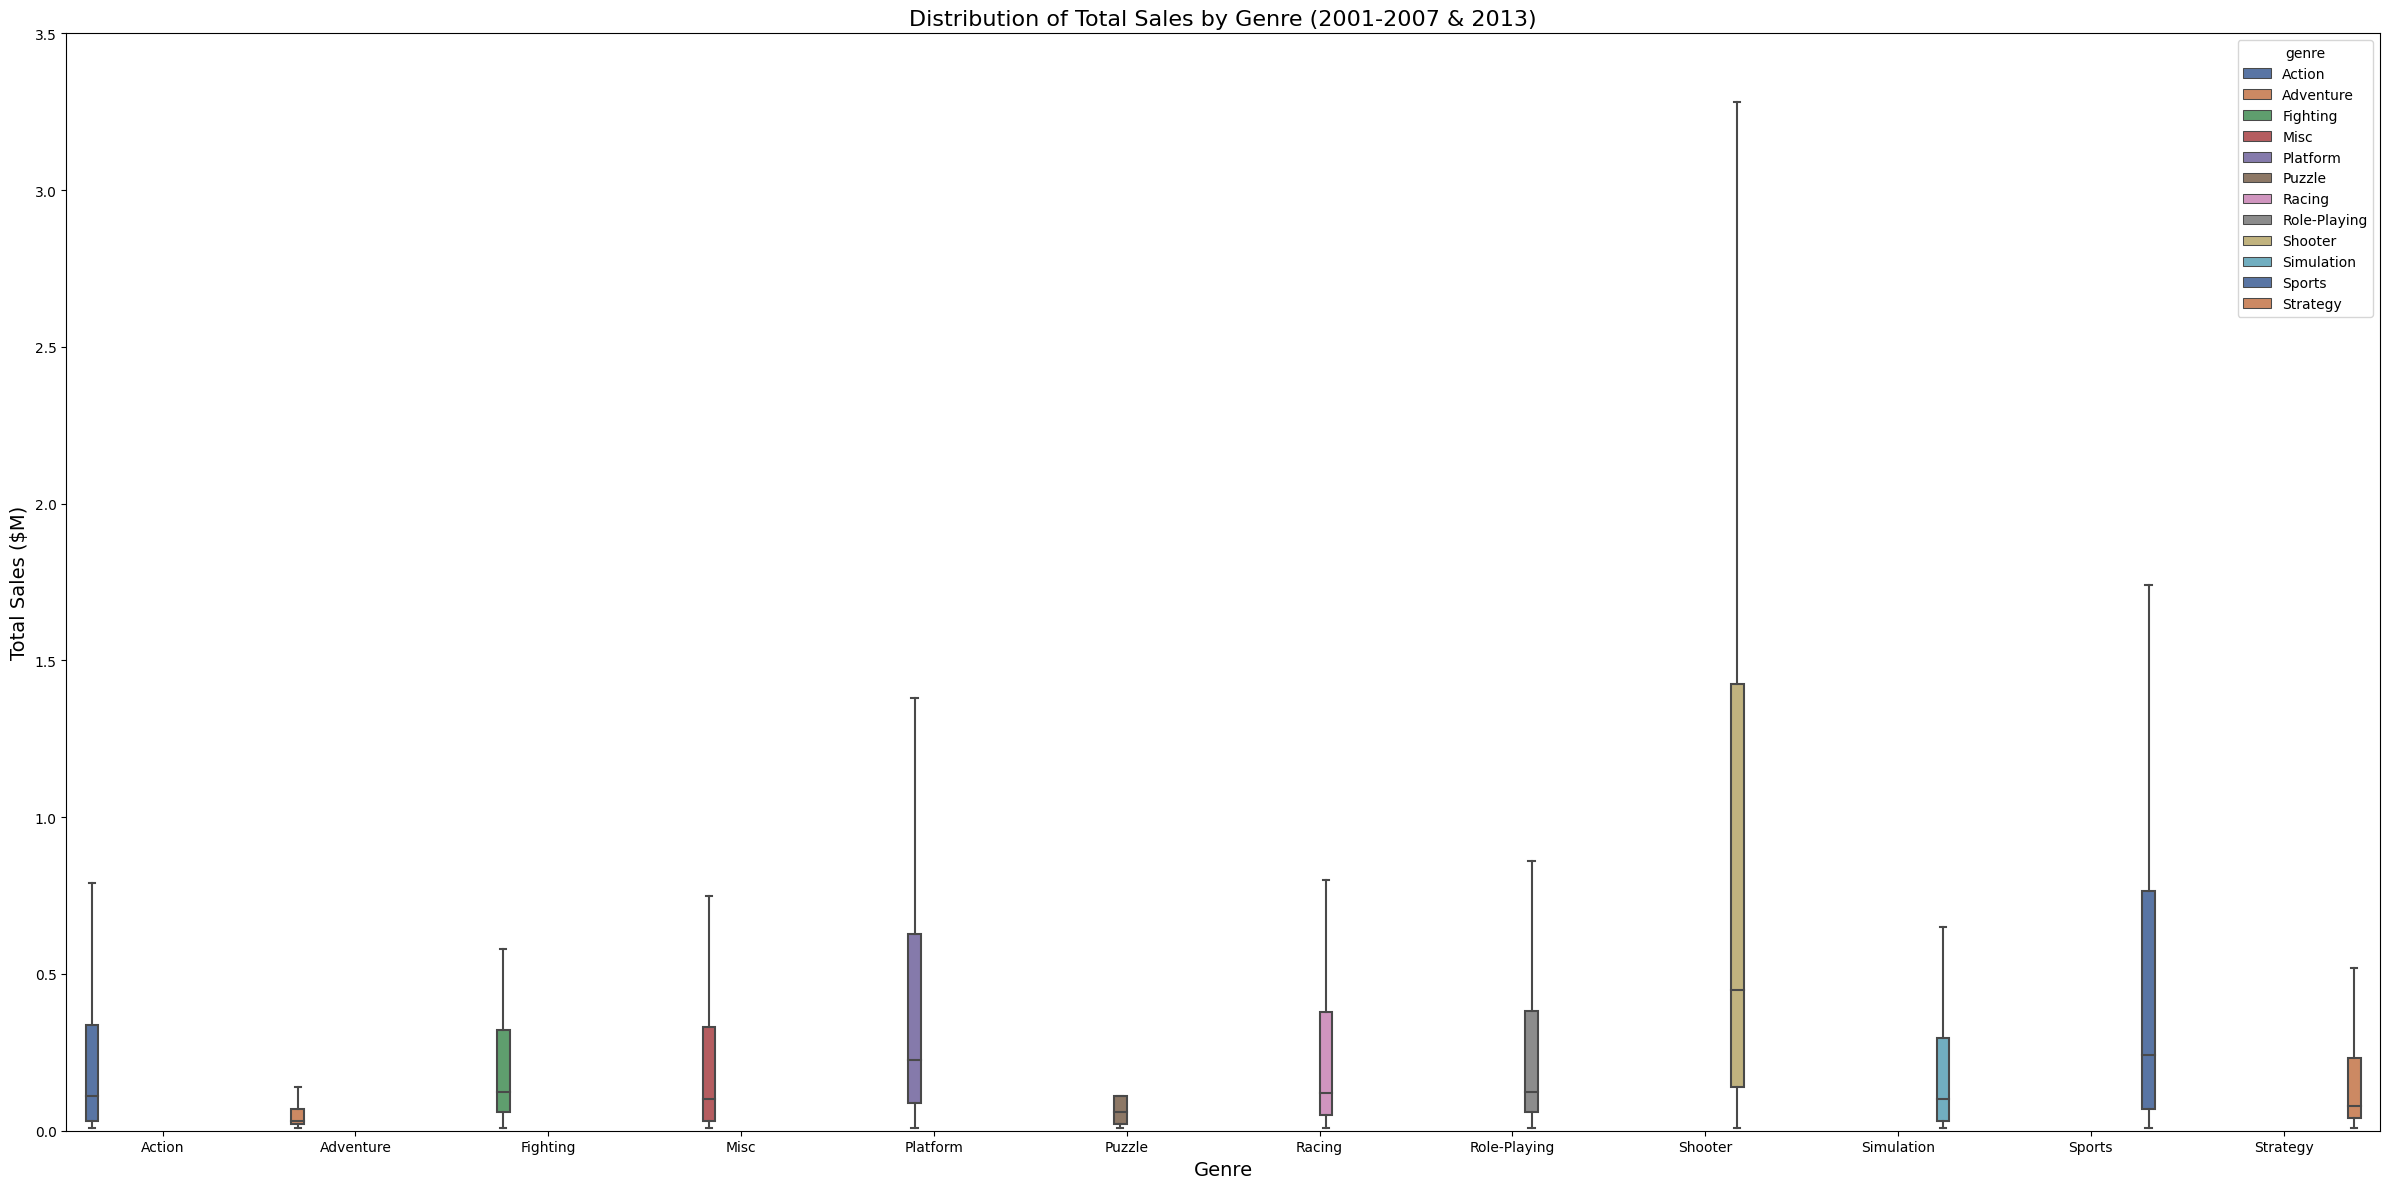

In [49]:
# Visualize genre distribution
plt.figure(figsize=[24,12])
sns.boxplot(
    data=games_filtered,
    x='genre',
    y='total_sales',
    hue='genre',
    palette='deep',
    showfliers=False
)

plt.title('Distribution of Total Sales by Genre (2001-2007 & 2013)', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Total Sales ($M)', fontsize=14)
plt.ylim(0,3.5)
plt.tight_layout()
plt.show()


In [50]:
# Calculate market share for each genre
genre_sales['market_share'] = (genre_sales['total_sales'] / genre_sales['total_sales'].sum() * 100).round(2)
# Sort genres by market share
genre_sales = genre_sales.sort_values(by='market_share', ascending=False)
# Display market share
print(genre_sales[['genre', 'market_share']])

           genre  market_share
0         Action         29.51
8        Shooter         21.36
10        Sports         13.81
7   Role-Playing         13.38
3           Misc          5.76
4       Platform          3.91
6         Racing          3.66
2       Fighting          3.24
1      Adventure          2.17
9     Simulation          2.00
11      Strategy          0.92
5         Puzzle          0.29


In [51]:
# Calculate the YoY growth for each genre
# Step 1: Group by year and genre, then sum the total sales
genre_yoy_growth = games_filtered.groupby(['year_of_release', 'genre'], observed=False)['total_sales'].sum().unstack()
# Step 2: Calculate the YoY growth
genre_yoy_growth = genre_yoy_growth.pct_change() * 100
# Step 3: Fill NaN values with 0
genre_yoy_growth = genre_yoy_growth.fillna(0).round(2)
genre_yoy_growth = genre_yoy_growth.drop(index=2013)

# print(genre_yoy_growth)

# Step 4: Identify any generes with consistent growth
years = genre_yoy_growth.index.sort_values()
last_year = years[-1]
eval_years = years[-2
                :-1]  # Last 3 years for evaluation
# Step 5: Check if the growth is positive for the last 3 years
consistent_growth_genres = []
trend_df = genre_yoy_growth.loc[eval_years]
upward_trend = trend_df.mean().loc[lambda x: x > 0].index.tolist()

print(f'Genres with consistent YoY growth from 2013 to 2016: {upward_trend}')

genre_yoy_growth = genre_yoy_growth.transpose()
# Calculate the mean and standard deviation of total sales for each genre
genre_yoy_growth['mean']  = games_filtered.groupby('genre', observed=False)['total_sales'].mean().round(3)
genre_yoy_growth['std'] = games_filtered.groupby('genre', observed=False)['total_sales'].std().round(3)
genre_yoy_growth['cv'] = (genre_yoy_growth['std'] / genre_yoy_growth['mean']).round(3)
# Sort genres by coefficient of variation (CV)
genre_yoy_growth = genre_yoy_growth.sort_values(by='mean', ascending=False)
print(genre_yoy_growth[['mean', 'std', 'cv']])
# Calculate the coefficient of variation (CV) for each genre


Genres with consistent YoY growth from 2013 to 2016: ['Adventure', 'Shooter', 'Simulation', 'Strategy']
year_of_release   mean    std     cv
genre                               
Shooter          1.246  2.014  1.616
Sports           0.704  1.219  1.732
Platform         0.576  0.807  1.401
Role-Playing     0.500  1.353  2.706
Racing           0.469  0.964  2.055
Fighting         0.441  1.049  2.379
Action           0.420  1.254  2.986
Misc             0.405  1.008  2.489
Simulation       0.351  0.849  2.419
Puzzle           0.186  0.325  1.747
Strategy         0.180  0.279  1.550
Adventure        0.096  0.216  2.250


<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>  Even though I think there are several different ways to measure performance, I fell back on using sales as my guiding factor. When plotting out the distribution the outliers had the data so skewed that I ended up limiting the chart to only showing the $1.5M in sales which made up the bulk of the data. 
    1. Which Genres consistently perform well? Based on the sales data, the Action, Sports, and Shooter genres are the top 3 grabbing over half of the market share at 64.7%. 
    2. Are there any genres showing recent growth or decline? Looking at the last 3 years of the filtered dataset (2013-2016), on average it looks like all genres are experiencing growth. However, looking at just the percent of change between 2006 and 2007 only Adventure, Shooter, Simulation, and Strategy showed a positive growth. 
    3. How does the average performance vary across genres? When looking at the average performance across genres the mean sales for each genre varies between $96K for Adventure all the way to $1.3M for Shooter games, that is a difference in $1.2M. However, the most volatile genre is Action with a CV of 2.986. 
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Great evaluation! This could be a valuable insight for a store manager.

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.



<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>   Since the next few tasks are basically looking for the same information, i have modularized 3 functions to use to perform a market analysis of the Platforms, Genres, and ESRB ratings.
</div>

In [52]:
# Create 3 modular functions to use in the Regional Market Analysis
# Function to compute regional sales shares
def compute_regional_sales_share(df, group_col, regional_sales_col, total_sales_col):
    # Combine regional sales columns with total sales column
    regional_sales_grpd = df.groupby(group_col, observed=False)[regional_sales_col + [total_sales_col]].sum()
    regional_sales_grpd = regional_sales_grpd.reset_index()
    regional_sales_grpd = regional_sales_grpd.sort_values(by=total_sales_col, ascending=False)
    regional_sales_grpd['regional_sales_share'] = regional_sales_grpd[total_sales_col] / regional_sales_grpd[total_sales_col].sum() * 100
    regional_sales_grpd['regional_sales_share'] = regional_sales_grpd['regional_sales_share'].round(2)
    regional_sales_grpd = regional_sales_grpd.set_index(group_col)
    return regional_sales_grpd

# Function to analyze market share by region
def analyze_market_share(df, group_col, regions):
    market_share = {}

    for region in regions:
        region_data = df.groupby(group_col, observed=False)[region].sum()
        share = (region_data / region_data.sum()) * 100
        market_share[region] = share.round(2)
    return pd.DataFrame(market_share)

# Function to compute bias score for each genre
def compute_bias(regional_share_df, global_share_series):
    """compute bias score as regional % / global %, handling index alignment
    
    Parameters:
    - regional_share_df: pd.DataFrame with group names as index and regions as columns
    - global_share_series: pd.Series of global share values"""
    # Align and validate indices
    shared_index = regional_share_df.index.intersection(global_share_series.index)
    regional_share_df = regional_share_df.loc[shared_index]
    global_share_series = global_share_series.loc[shared_index]
    
    # Bias score = regional % / global %
    bias_df = regional_share_df.divide(global_share_series, axis=0)
    bias_df = bias_df.round(2) 
    return bias_df

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [53]:
# Function to analyze platform performance by region
# See Student Comment above right under Step 4: Regional Market Analysis

In [54]:
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
# Analyze each region
platform_regional_performance = compute_regional_sales_share(games_filtered, 'platform', regions, 'total_sales')
platform_regional_market_share = analyze_market_share(games_filtered, 'platform', regions)
platform_bias_score = compute_bias(platform_regional_market_share, platform_regional_performance['regional_sales_share'])

# platform_regional_performance.info()
# platform_regional_market_share.info()
# platform_bias_score.info()

### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [55]:
# Create a comparative platform analysis
# Rename columns for clarity
platform_regional_performance.columns = [
    'NA Sales ($M)', 
    'EU Sales ($M)', 
    'JP Sales ($M)', 
    'Other Sales ($M)', 
    'Total Sales ($M)',
    'Regional Share (%)'
]

platform_regional_market_share.columns = [
    'NA Share (%)', 
    'EU Share (%)', 
    'JP Share (%)', 
    'Other Share (%)'
]

platform_bias_score.columns = [
    'NA Bias Score', 
    'EU Bias Score', 
    'JP Bias Score', 
    'Other Bias Score'
]

platform_comparison = pd.concat([
    platform_regional_performance,
    platform_regional_market_share,
    platform_bias_score
], axis=1)

# Sort by Total Sales
platform_comparison = platform_comparison.sort_values(by='Total Sales ($M)', ascending=False)

# platform_comparison.info()

<Figure size 2400x1000 with 0 Axes>

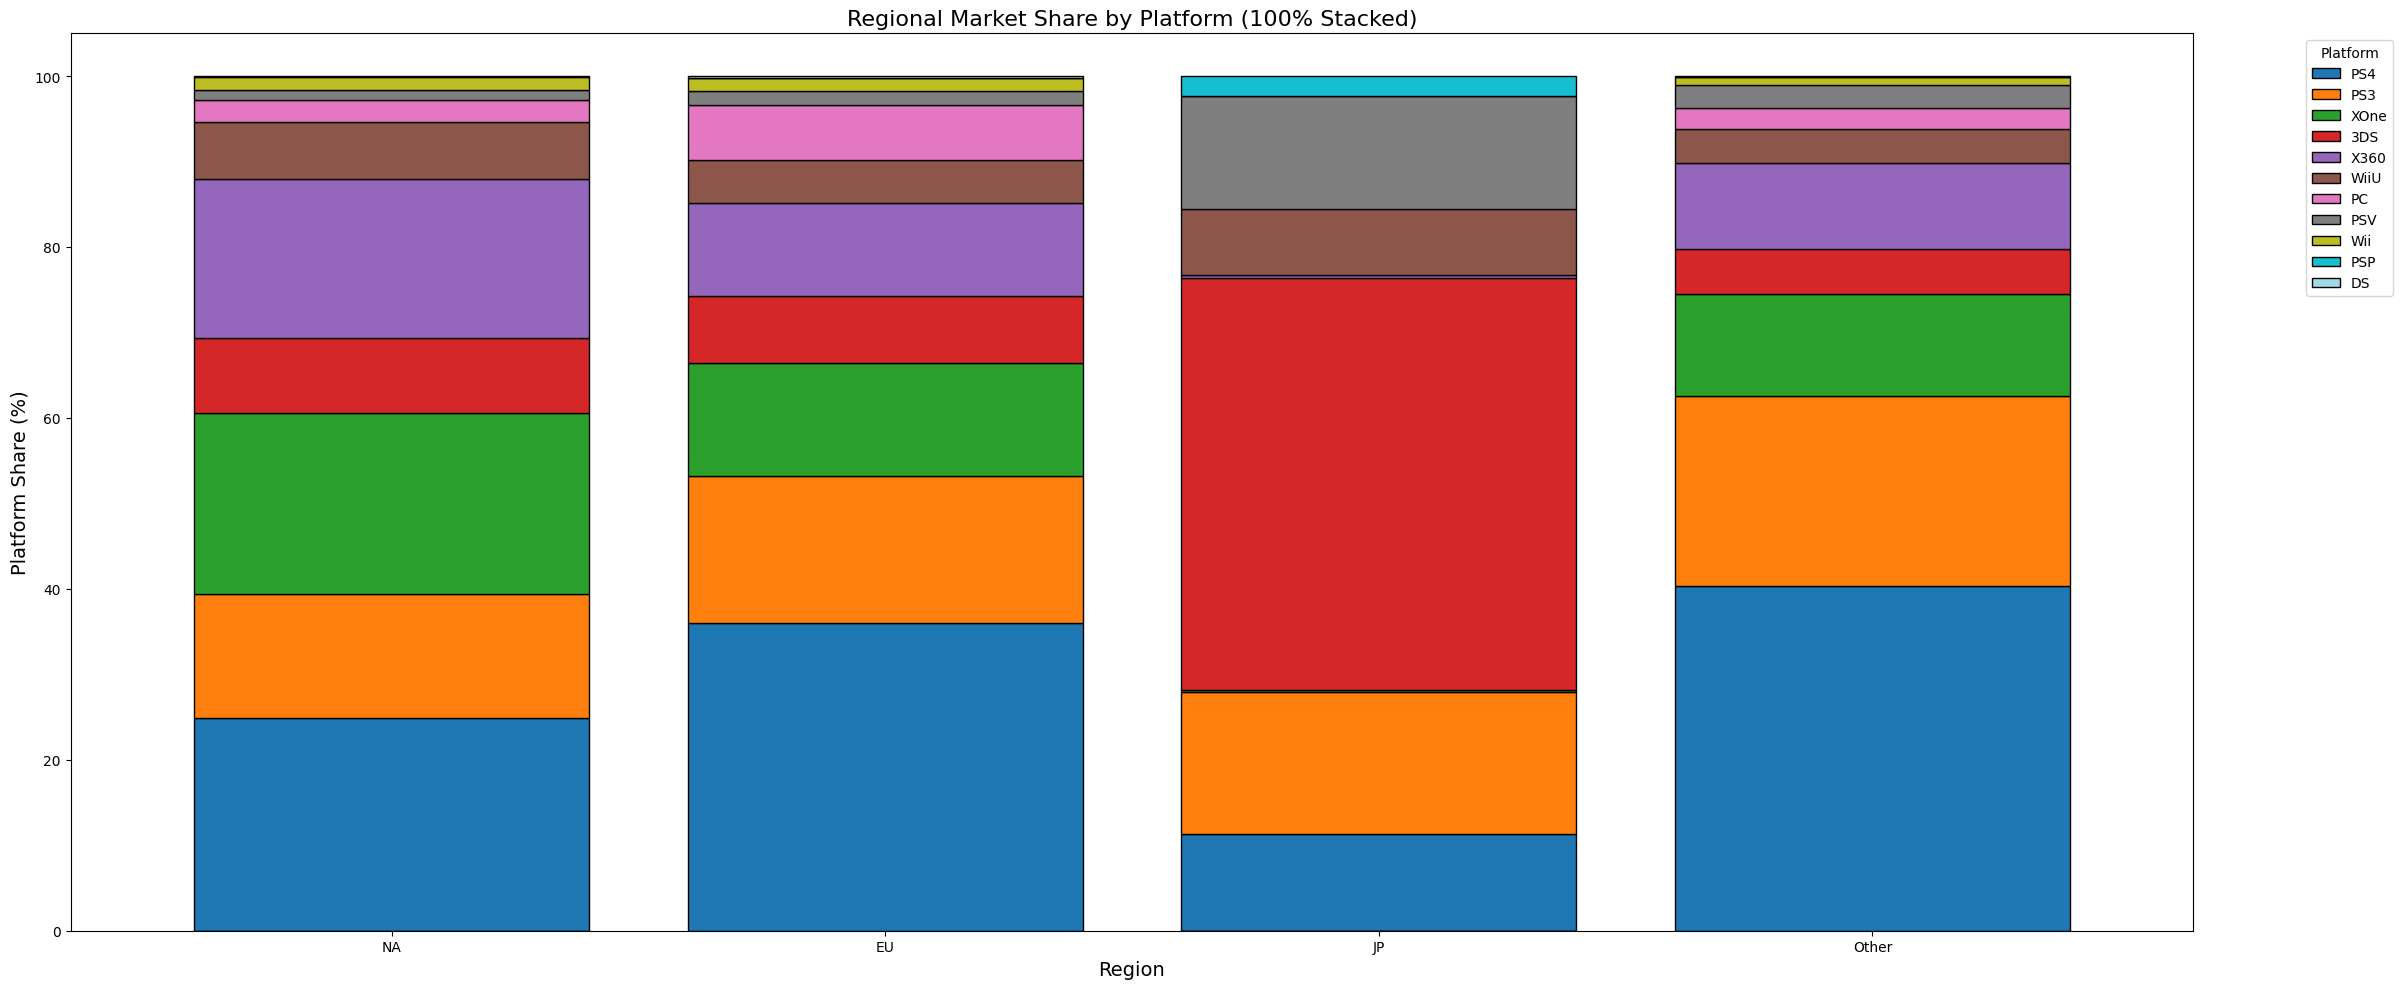

In [56]:
# Step 1: Select and clean up regional sales
region_sales = platform_comparison[
    ['NA Sales ($M)', 'EU Sales ($M)', 'JP Sales ($M)', 'Other Sales ($M)']
].copy()

region_sales.columns = ['NA', 'EU', 'JP', 'Other']

# Step 2: Transpose so regions become rows
region_sales_T = region_sales.T

# Step 3: Normalize each region to 100%
region_sales_percent = region_sales_T.div(region_sales_T.sum(axis=1), axis=0) * 100

# Step 4: Sort platforms by total global sales (same order for stacking)
platform_order = platform_comparison['Total Sales ($M)'].sort_values(ascending=False).index
region_sales_percent = region_sales_percent[platform_order]

# Step 5: Plot it
plt.figure(figsize=(24,10))
region_sales_percent.plot(
    kind='bar',
    stacked=True,
    colormap='tab20',
    edgecolor='black',
    figsize=(24, 10),
    width=0.8
)

plt.title('Regional Market Share by Platform (100% Stacked)', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Platform Share (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [57]:
# Function to analyze genre performance by region
# See Student Comment above right under Step 4: Regional Market Analysis

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [58]:
# Create a comparative genre analysis
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
# Analyze each region
genre_regional_performance = compute_regional_sales_share(games_filtered, 'genre', regions, 'total_sales')
genre_regional_market_share = analyze_market_share(games_filtered, 'genre', regions)
genre_bias_score = compute_bias(genre_regional_market_share, genre_regional_performance['regional_sales_share'])

# genre_regional_performance.info()
# genre_regional_market_share.info()
# genre_bias_score.info()

In [59]:
# Rename columns for clarity
genre_regional_performance.columns = [
    'NA Sales ($M)', 
    'EU Sales ($M)', 
    'JP Sales ($M)', 
    'Other Sales ($M)', 
    'Total Sales ($M)',
    'Regional Share (%)'
]

genre_regional_market_share.columns = [
    'NA Share (%)', 
    'EU Share (%)', 
    'JP Share (%)', 
    'Other Share (%)'
]

genre_bias_score.columns = [
    'NA Bias Score', 
    'EU Bias Score', 
    'JP Bias Score', 
    'Other Bias Score'
]

genre_comparison = pd.concat([
    genre_regional_performance,
    genre_regional_market_share,
    genre_bias_score
], axis=1)

# Sort by Total Sales
genre_comparison = genre_comparison.sort_values(by='Total Sales ($M)', ascending=False)

# print(genre_comparison.head())

<Figure size 2400x1000 with 0 Axes>

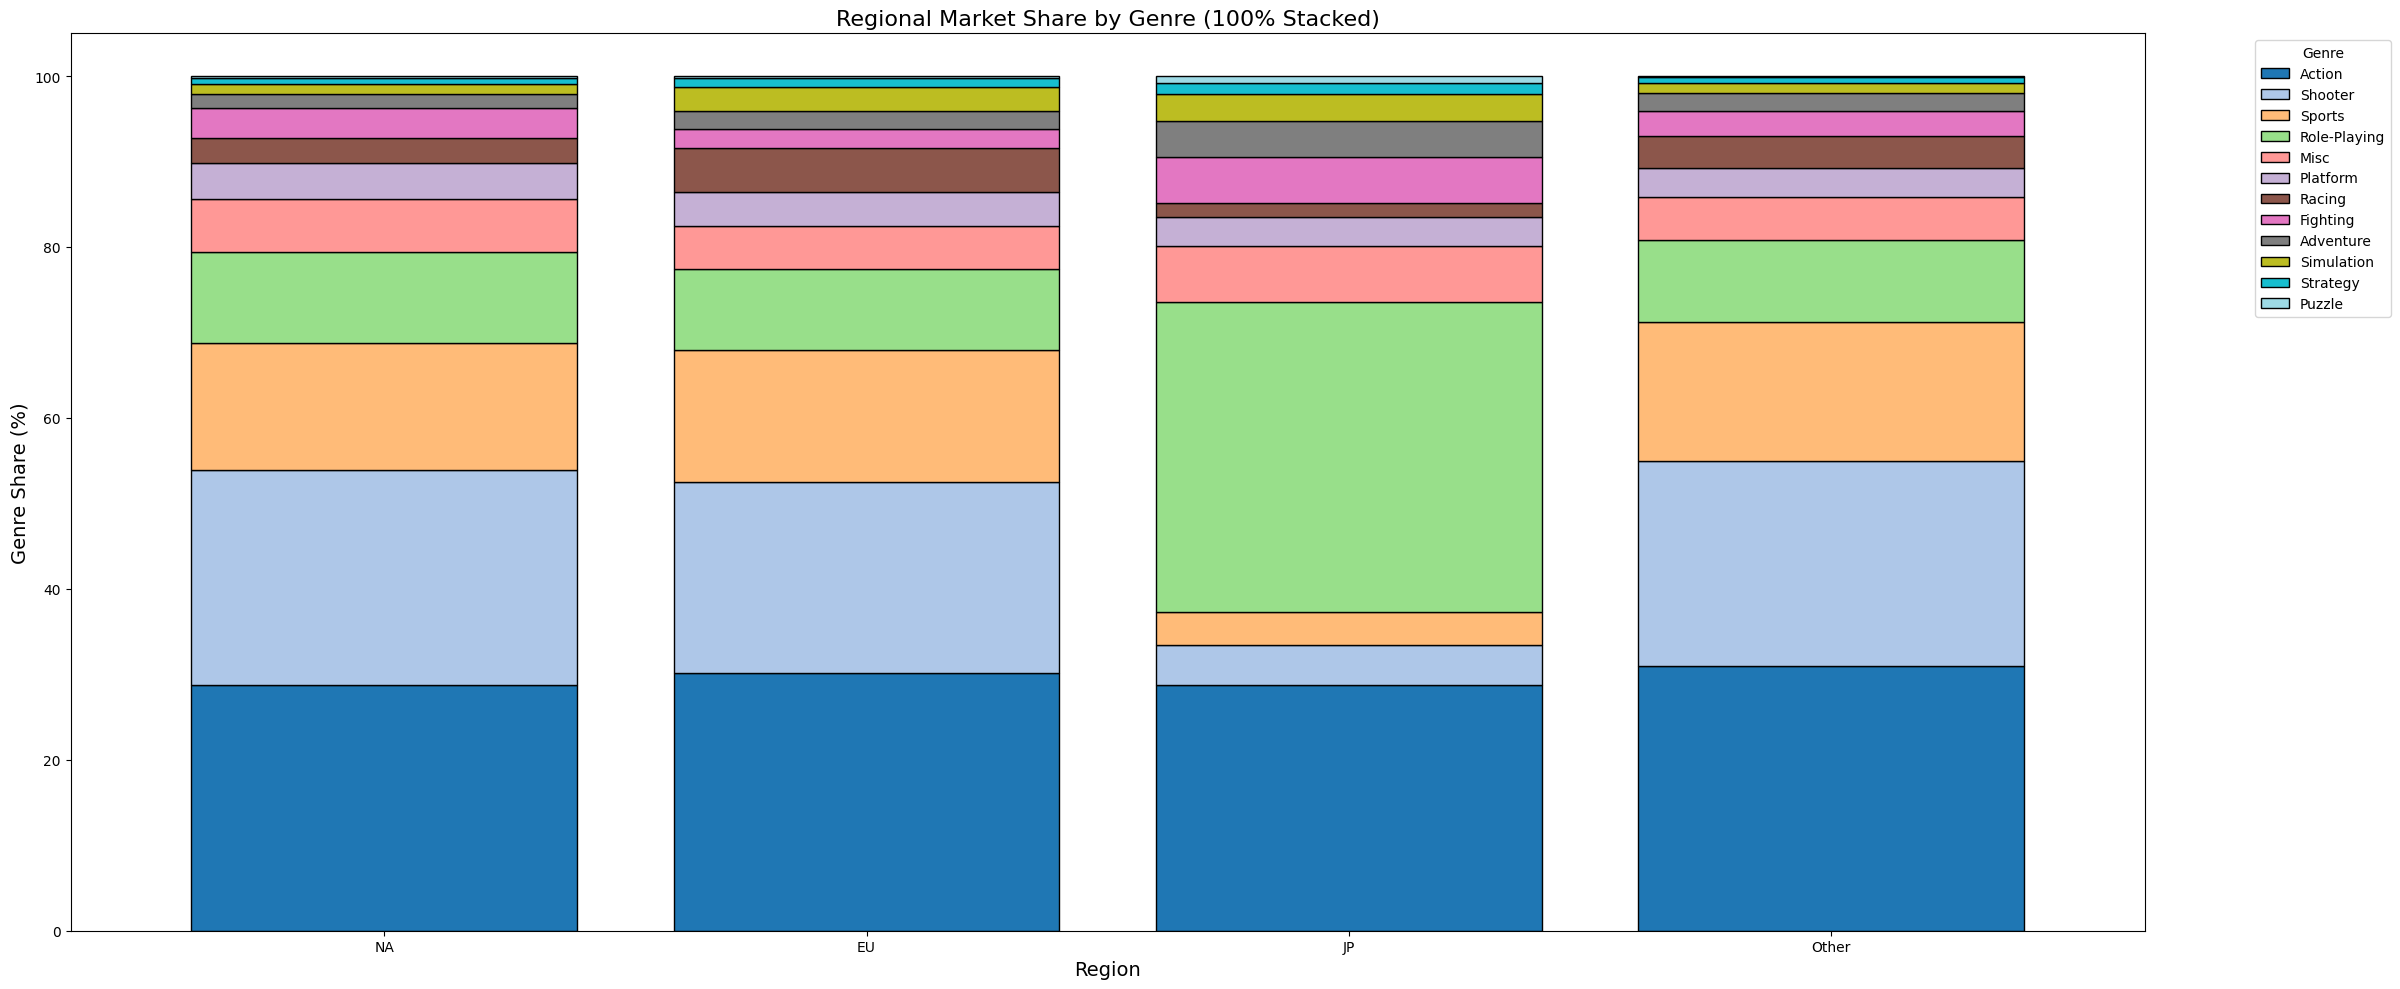

In [60]:
# Step 1: Select and clean up regional sales
region_genre = genre_comparison[
    ['NA Sales ($M)', 'EU Sales ($M)', 'JP Sales ($M)', 'Other Sales ($M)']
].copy()

region_genre.columns = ['NA', 'EU', 'JP', 'Other']

# Step 2: Transpose so regions become rows
region_genre_T = region_genre.T

# Step 3: Normalize each region to 100%
region_genre_percent = region_genre_T.div(region_genre_T.sum(axis=1), axis=0) * 100

# Step 4: Sort platforms by total global sales (same order for stacking)
genre_order = genre_comparison['Total Sales ($M)'].sort_values(ascending=False).index
region_genre_percent = region_genre_percent[genre_order]

# Step 5: Plot it
plt.figure(figsize=(24,10))
region_genre_percent.plot(
    kind='bar',
    stacked=True,
    colormap='tab20',
    edgecolor='black',
    figsize=(24, 10),
    width=0.8
)

plt.title('Regional Market Share by Genre (100% Stacked)', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Genre Share (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [61]:
# Function to analyze ESRB rating impact
# See Student Comment above right under Step 4: Regional Market Analysis

In [62]:
# Analyze ESRB impact for each region
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
# Analyze each region
rating_regional_performance = compute_regional_sales_share(games_filtered, 'rating', regions, 'total_sales')
rating_regional_market_share = analyze_market_share(games_filtered, 'rating', regions)
rating_bias_score = compute_bias(rating_regional_market_share, rating_regional_performance['regional_sales_share'])

# rating_regional_performance.info()
# print(rating_regional_performance.head(10))
# rating_regional_market_share.info()
# rating_bias_score.info()

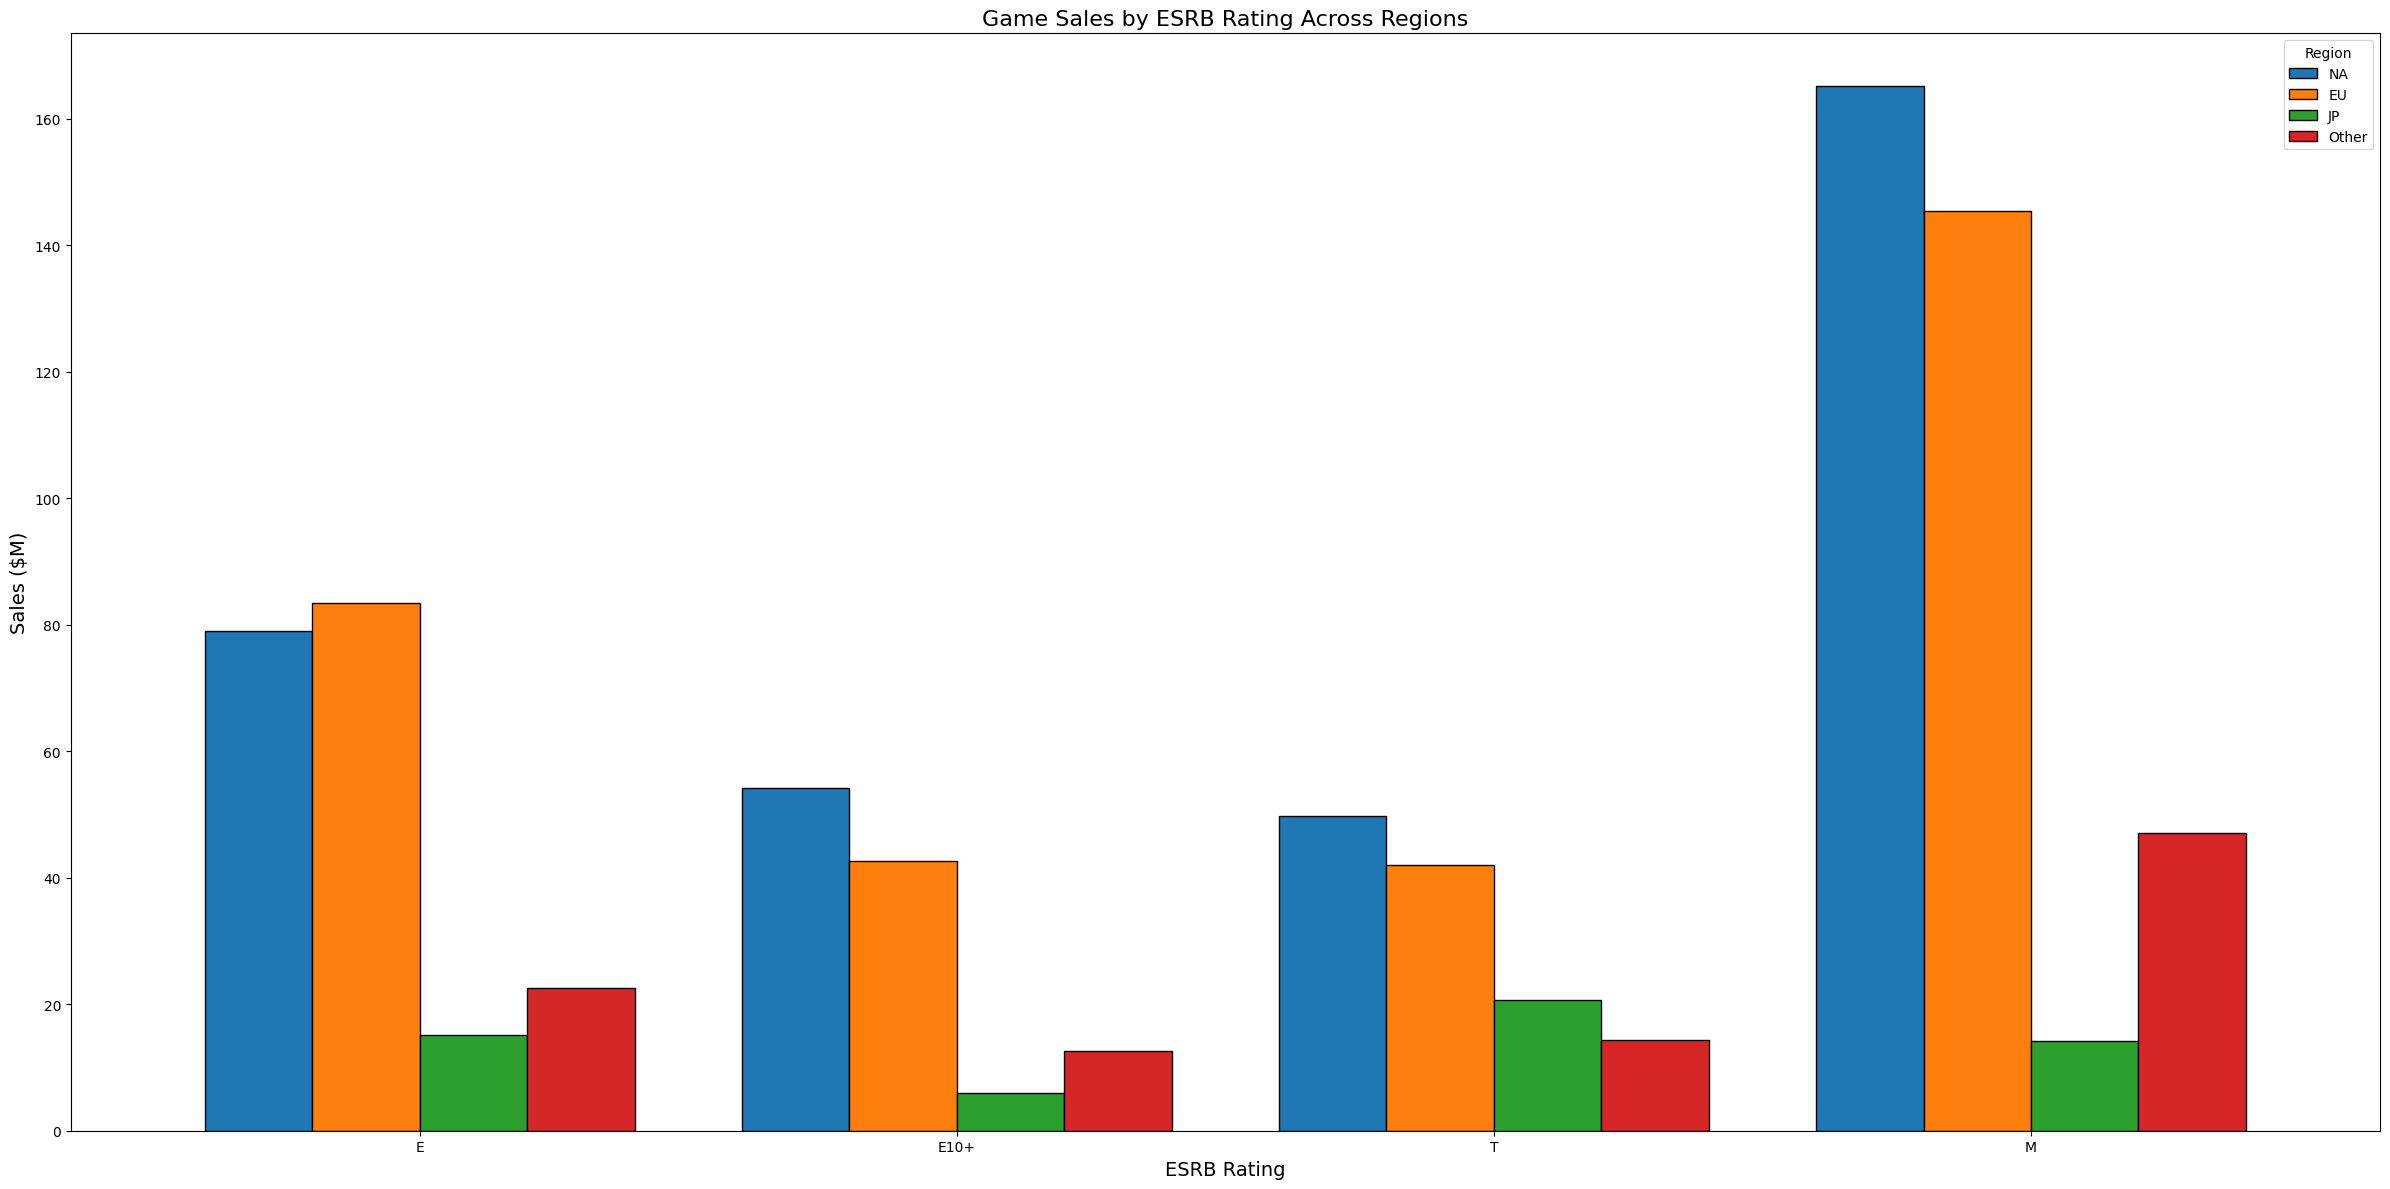

In [63]:
# Dropping irrelevant ratings
ratings_to_drop = ['AO', 'RP', 'EC', 'Unknown']
rating_regional_performance_drop = rating_regional_performance.drop(index=ratings_to_drop, errors='ignore')

# Drop 'total_sales' & 'regional_sales_share' columns
cols_to_drop = ['total_sales', 'regional_sales_share']
rating_regional_performance_drop = rating_regional_performance_drop.drop(columns=cols_to_drop, errors='ignore')

# Rename columns for clarity
rating_regional_performance_drop.rename(columns={
    'na_sales': 'NA', 
    'eu_sales': 'EU', 
    'jp_sales': 'JP', 
    'other_sales': 'Other'
}, inplace=True)

# Clean up rating order
rating_order = ['E', 'E10+', 'T', 'M']
rating_regional_performance_drop = rating_regional_performance_drop.reindex([r for r in rating_order if r in rating_regional_performance_drop.index])

# Plot it as a grouped bar chart
rating_regional_performance_drop.plot(
    kind='bar',
    figsize=(24,12),
    width=0.8,
    edgecolor='black'
)

plt.title('Game Sales by ESRB Rating Across Regions', fontsize=16)
plt.xlabel('ESRB Rating', fontsize=14)
plt.ylabel('Sales ($M)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Region', fontsize=10)
plt.tight_layout()
plt.show()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Everything looks great! 

As a second approach, you could also arrange subplots using plotly in the following way: 
    
```
# Create individual pie charts with Plotly Express
fig_jp = px.pie(jpesrb_sort, values='jp_sales', names='rating', title='ESRB-JP')
fig_eu = px.pie(euesrb_sort, values='eu_sales', names='rating', title='ESRB-EU')
fig_na = px.pie(naesrb_sort, values='na_sales', names='rating', title='ESRB-NA')

# Create a subplot grid with 1 row and 3 columns
fig = make_subplots(rows=1, cols=3, specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}]])

# Add each pie chart to the subplot
fig.add_trace(fig_jp.data[0], row=1, col=1)
fig.add_trace(fig_eu.data[0], row=1, col=2)
fig.add_trace(fig_na.data[0], row=1, col=3)

# Update layout to show the titles properly
fig.update_layout(title_text="ESRB Ratings Comparison", showlegend=False)

# Show the combined plot
fig.show()
```

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>
Null Hypothesis: The average user rating of the Xbox One and the PC gaming platform are equal.

Alternative Hypothesis: The average user rating of the Xbox One and the PC gaming platform are not equal.
</div>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Great work formulating hypotheses for each question.

In [64]:
# Step 1: Filter platforms for Xbox One and PC & drop missing values
xbox_scores = games_filtered[games_filtered['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games_filtered[games_filtered['platform'] == 'PC']['user_score'].dropna()

# Step 2: Run ttest_ind
alpha = 0.5

platform_results = st.ttest_ind(xbox_scores, pc_scores)

print('pvalue: ', platform_results.pvalue)

if platform_results.pvalue < alpha:
    print("We reject the null hypothesis.")
else:
    print("We can't reject the null hypothesis.")


pvalue:  0.1401265840361173
We reject the null hypothesis.


<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>
Null Hypothesis: The average user rating for Action and Sports genre games are different.

Alternative Hypothesis: The average user rating for Action and Sports genre games are the same.
</div>

In [66]:
# Step 1: Filter platforms for genres Action and Sports & drop missing values
action_scores = games_filtered[games_filtered['genre'] == 'Action']['user_score'].dropna()
sports_scores = games_filtered[games_filtered['genre'] == 'Sports']['user_score'].dropna()

# Step 2: Run ttest_ind
alpha = 0.5

genre_results = st.ttest_ind(action_scores, sports_scores)

print('pvalue: ', genre_results.pvalue)

if genre_results.pvalue < alpha:
    print("We reject the null hypothesis.")
else:
    print("We can't reject the null hypothesis.")

pvalue:  1.0517832389140778e-27
We reject the null hypothesis.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Reviewer's comment v1:</b>

Great job! Your results and conclusions are correct.

You've correctly stated the null and alternative hypotheses for both tests. It's always good practice to write these out explicitly, as you did.

Additionally, before testing your hypotheses, you can compare the variances of the samples to determine which value to use for the <code>equal_var</code> parameter in the <code>ttest_ind</code> method (by default, it is set to <code>True</code>). You can calculate the variances manually, or use Levene’s test or Bartlett’s test to check for equality of variances.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bartlett.html

</div>

# Step 6. Write a general conclusion


This analysis was performed to determine market trends globally as well as regionally. This information would then be used as a guide for a sales campaign for 2017. Using EDA and statistical analysis, it was determined that there was a strong demand for video games between 2001 and 2007 with another small uptick in 2013. However I utilized the most recent 2013 to 2016 timespan to determin if there were any patterns to what video games people purchased. The biggest challenge with the initial data set was the large number of missing values in some key areas. This is why I create the triple axis plot to illustrate why choosing 2001-2007, 2013 was the right choice, but even then I had to lower my threshold on missing vlaues to no more than 50% of missing data.

The data shows that during this timespan, people were moving from the PS3 to the PS4 and from the Xbox 360 to the Xbox One. From that information, one can conclude that consumers around the world prefer to keep up with new technology in the video gaming industry. From looking at the market shares based on genres, the clear winner is those games in the Action genre, with Shooter coming in second around the world.

As I looked at the different platforms I took a look at the user scores between the Xbox One and the PC. Initially, I thought more consumers would have rated the Xbox One equal to the PC gaming experience; however, the statistical analysis clearly shows that users have a differnet view of which is a better experience. Then I looked at the user scores of Action and Sports games...thinking that since Action games took the larger piece of the market the user scores would align with that. However, that was not the case. After running the Welch test it is clear that globally users would rate the game play of Action and Sports genres the same.

My recommendation would be to focus on the newer platforms along with Action and Sports games. This would be my focus for the next sales campaign.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
You did an excellent job analyzing the data and drawing conclusions!

It’s great that you pay attention to formulating interim conclusions in your project-this is an excellent practice that will benefit you in future projects. Keep using this approach, as it makes your analysis more structured and easier for readers and colleagues to understand.

Additionally, it’s fantastic that you included valuable insights about trends in the gaming industry. You did a great job highlighting key points and interpreting them clearly.

Overall, excellent work! Keep it up! 😊